In [ ]:
from PIL import Image
import numpy as np
from sklearn.decomposition import PCA
import os

def resize_and_extract_rgb(image_path, size=(10, 10)):
    image = Image.open(image_path)
    image_resized = image.resize(size)
    rgb_data = np.array(image_resized)
    return rgb_data

def create_cartesian_joint(rgb_data):
    cartesian_joint = np.array(np.meshgrid(rgb_data[:, :, 0].flatten(), rgb_data[:, :, 1].flatten(), rgb_data[:, :, 2].flatten())).T.reshape(-1,3)
    return cartesian_joint

def apply_pca(cartesian_joint, n_components=3):
    pca = PCA(n_components=n_components)
    reduced_data = pca.fit_transform(cartesian_joint)
    return reduced_data

def create_robinson_matrix(reduced_data):
    size = reduced_data.shape[0]
    robinson_matrix = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            robinson_matrix[i, j] = np.linalg.norm(reduced_data[i] - reduced_data[j])
    robinson_matrix.sort(axis=1)
    return robinson_matrix

def weighted_minkowski_distance(a, b, p=2, weights=None):
    """Hitung jarak Minkowski yang digeneralisasi antara dua vektor."""
    if weights is None:
        weights = np.ones(a.shape)
    return np.sum(weights * np.abs(a - b) ** p) ** (1 / p)

def kmeans_custom(robinson_matrices, centroids, max_iter=100, p=2):
    """Implementasi k-means dengan jarak Minkowski yang digeneralisasi."""
    labels = np.zeros(len(robinson_matrices))
    for iteration in range(max_iter):
        # Langkah Assignment
        for i, matrix in enumerate(robinson_matrices):
            distances = [weighted_minkowski_distance(matrix, centroid, p) for centroid in centroids]
            labels[i] = np.argmin(distances)

        # Langkah Update
        new_centroids = []
        for j in range(len(centroids)):
            cluster_points = [robinson_matrices[i] for i in range(len(robinson_matrices)) if labels[i] == j]
            if cluster_points:  # Cek apakah ada titik dalam cluster
                new_centroids.append(np.mean(cluster_points, axis=0))
            else:  # Jika tidak ada titik dalam cluster, gunakan centroid lama
                new_centroids.append(centroids[j])
        centroids = new_centroids

    return labels, centroids

folder_path = '/content/drive/MyDrive/Colab Notebooks/MAWAR MERAH dan BIRU'
image_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.jpg')]

robinson_matrices = []
image_names = []  # Menyimpan nama gambar

robinson_matrices = []
for image_path in image_paths:
    rgb_data = resize_and_extract_rgb(image_path)
    cartesian_joint = create_cartesian_joint(rgb_data)
    reduced_data = apply_pca(cartesian_joint)
    robinson_matrix = create_robinson_matrix(reduced_data)
    robinson_matrices.append(robinson_matrix.flatten())

# Ambil matriks Robinson untuk "MM 1.jpg" dan "MB 1.jpg" sebagai centroid awal
initial_centroids = [create_robinson_matrix(resize_and_extract_rgb(os.path.join(folder_path, "MM 1.jpg"))).flatten(),
                     create_robinson_matrix(resize_and_extract_rgb(os.path.join(folder_path, "MB 1.jpg"))).flatten()]

# Clustering dengan k-means custom dan jarak Minkowski yang digeneralisasi
labels, final_centroids = kmeans_custom(robinson_matrices, initial_centroids)

# Mencetak label bersama dengan nama file yang sesuai
for label, image_name in zip(labels, image_names):
    print(f"{image_name}: Cluster {label}")

KeyboardInterrupt: 

In [ ]:
from PIL import Image
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import os

def resize_and_extract_rgb(image_path, size=(50, 50)):
    image = Image.open(image_path)
    image_resized = image.resize(size)
    rgb_data = np.array(image_resized)
    return rgb_data.flatten()  # Meratakan array menjadi 1D

def apply_pca(rgb_data, n_components=3):
    pca = PCA(n_components=n_components)
    reduced_data = pca.fit_transform(rgb_data.reshape(-1, 3))  # Mengubah kembali ke bentuk (N, 3) untuk PCA
    return reduced_data.flatten()  # Meratakan kembali setelah PCA

folder_path = '/content/drive/MyDrive/Colab Notebooks/MAWAR MERAH dan BIRU'
image_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.jpg')]
image_names = [os.path.basename(f) for f in image_paths]  # Menyimpan nama gambar

reduced_data_list = []
for image_path in image_paths:
    rgb_data = resize_and_extract_rgb(image_path)
    reduced_data = apply_pca(rgb_data)
    reduced_data_list.append(reduced_data)

# K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=0).fit(reduced_data_list)
labels = kmeans.labels_

# Mencetak label bersama dengan nama file yang sesuai
for label, image_name in zip(labels, image_names):
    print(f"{image_name}: Cluster {label}")


MM 3.jpg: Cluster 0
MM 6.jpg: Cluster 0
MM 1.jpg: Cluster 0
MM 10.jpg: Cluster 0
MB 10.jpg: Cluster 0
MM 8.jpg: Cluster 0
MM 9.jpg: Cluster 0
MM 7.jpg: Cluster 0
MB 2.jpg: Cluster 0
MM 4.jpg: Cluster 0
MM 5.jpg: Cluster 0
MM 2.jpg: Cluster 0
MB 1.jpg: Cluster 0
MB 8.jpg: Cluster 0
MB 9.jpg: Cluster 1
MB 4.jpg: Cluster 0
MB 3.jpg: Cluster 0
MB 6.jpg: Cluster 0
MB 7.jpg: Cluster 0
MB 5.jpg: Cluster 0


bunga mawar interval

In [ ]:
from PIL import Image
import numpy as np
import os

def get_rgb_ranges(image_paths):
    # Inisialisasi list untuk menyimpan nilai min dan max dari setiap channel secara terpisah
    min_red, min_green, min_blue = [], [], []
    max_red, max_green, max_blue = [], [], []

    for image_path in image_paths:
        # Membaca gambar dan mengkonversinya ke array numpy
        image = Image.open(image_path)
        image_data = np.array(image)

        # Update list nilai min dan max untuk setiap channel
        min_red.append(image_data[:, :, 0].min())
        min_green.append(image_data[:, :, 1].min())
        min_blue.append(image_data[:, :, 2].min())

        max_red.append(image_data[:, :, 0].max())
        max_green.append(image_data[:, :, 1].max())
        max_blue.append(image_data[:, :, 2].max())

    # Mengembalikan nilai min dan max dari setiap channel
    return (min(min_red), max(max_red)), (min(min_green), max(max_green)), (min(min_blue), max(max_blue))

# Folder yang berisi gambar bunga mawar merah dan biru
red_rose_folder = '/content/drive/MyDrive/Colab Notebooks/mawar merah'
blue_rose_folder = '/content/drive/MyDrive/Colab Notebooks/mawar biru'

# Dapatkan path gambar untuk masing-masing folder
red_image_paths = [os.path.join(red_rose_folder, f) for f in os.listdir(red_rose_folder) if f.endswith('.jpg')]
blue_image_paths = [os.path.join(blue_rose_folder, f) for f in os.listdir(blue_rose_folder) if f.endswith('.jpg')]

# Dapatkan interval RGB untuk bunga mawar merah
red_ranges = get_rgb_ranges(red_image_paths)
print(f"Bunga Mawar Merah - Interval Pixel Channel:")
print(f"Merah: {red_ranges[0]}, Hijau: {red_ranges[1]}, Biru: {red_ranges[2]}")

# Dapatkan interval RGB untuk bunga mawar biru
blue_ranges = get_rgb_ranges(blue_image_paths)
print(f"Bunga Mawar Biru - Interval Pixel Channel:")
print(f"Merah: {blue_ranges[0]}, Hijau: {blue_ranges[1]}, Biru: {blue_ranges[2]}")

from sklearn.cluster import KMeans

def interval_distance(interval1, interval2):
    """Menghitung jarak antara dua interval menggunakan titik tengah."""
    midpoint1 = (interval1[0] + interval1[1]) / 2
    midpoint2 = (interval2[0] + interval2[1]) / 2
    return abs(midpoint1 - midpoint2)

def get_image_interval(image_path):
    """Mendapatkan interval RGB untuk satu gambar."""
    image = Image.open(image_path)
    image_data = np.array(image)
    return (image_data[:, :, 0].min(), image_data[:, :, 0].max()), (image_data[:, :, 1].min(), image_data[:, :, 1].max()), (image_data[:, :, 2].min(), image_data[:, :, 2].max())

def cluster_images(test_folder, red_ranges, blue_ranges):
    test_image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith('.jpg')]
    intervals = [get_image_interval(path) for path in test_image_paths]
    intervals_flat = [(r[0], r[1], g[0], g[1], b[0], b[1]) for r, g, b in intervals]

    # Menggunakan interval RGB dari mawar merah dan biru sebagai centroid awal
    initial_centroids = np.array([
        [red_ranges[0][0], red_ranges[0][1], red_ranges[1][0], red_ranges[1][1], red_ranges[2][0], red_ranges[2][1]],
        [blue_ranges[0][0], blue_ranges[0][1], blue_ranges[1][0], blue_ranges[1][1], blue_ranges[2][0], blue_ranges[2][1]]
    ])

    # K-Means Clustering
    kmeans = KMeans(n_clusters=2, init=initial_centroids, n_init=1)
    kmeans.fit(intervals_flat)
    labels = kmeans.labels_

    # Mencetak hasil clustering
    for label, image_path in zip(labels, test_image_paths):
        print(f"{os.path.basename(image_path)}: Cluster {label}")

# Folder test yang berisi gambar bunga untuk di-klaster
test_folder = '/content/drive/MyDrive/Colab Notebooks/MAWAR MERAH dan BIRU'

# Melakukan clustering pada gambar bunga di folder test
cluster_images(test_folder, red_ranges, blue_ranges)



Bunga Mawar Merah - Interval Pixel Channel:
Merah: (np.uint8(21), np.uint8(255)), Hijau: (np.uint8(0), np.uint8(167)), Biru: (np.uint8(0), np.uint8(172))
Bunga Mawar Biru - Interval Pixel Channel:
Merah: (np.uint8(0), np.uint8(241)), Hijau: (np.uint8(0), np.uint8(255)), Biru: (np.uint8(19), np.uint8(255))
MM 3.jpg: Cluster 0
MM 6.jpg: Cluster 0
MM 1.jpg: Cluster 0
MM 10.jpg: Cluster 0
MB 10.jpg: Cluster 1
MM 8.jpg: Cluster 0
MM 9.jpg: Cluster 0
MM 7.jpg: Cluster 0
MB 2.jpg: Cluster 1
MM 4.jpg: Cluster 0
MM 5.jpg: Cluster 0
MM 2.jpg: Cluster 0
MB 1.jpg: Cluster 1
MB 8.jpg: Cluster 1
MB 9.jpg: Cluster 1
MB 4.jpg: Cluster 1
MB 3.jpg: Cluster 1
MB 6.jpg: Cluster 1
MB 7.jpg: Cluster 1
MB 5.jpg: Cluster 1


bunga anggrek interval

In [ ]:
from PIL import Image
import numpy as np
import os

def get_rgb_ranges(image_paths):
    min_red, min_green, min_blue = [], [], []
    max_red, max_green, max_blue = [], [], []
    for image_path in image_paths:
        image = Image.open(image_path)
        image_data = np.array(image)
        min_red.append(image_data[:, :, 0].min())
        min_green.append(image_data[:, :, 1].min())
        min_blue.append(image_data[:, :, 2].min())
        max_red.append(image_data[:, :, 0].max())
        max_green.append(image_data[:, :, 1].max())
        max_blue.append(image_data[:, :, 2].max())
    return (min(min_red), max(max_red)), (min(min_green), max(max_green)), (min(min_blue), max(max_blue))

# Folder yang berisi gambar bunga matahari dan anggrek
sunflower_folder = '/content/drive/MyDrive/Colab Notebooks/matahari'
orchid_folder = '/content/drive/MyDrive/Colab Notebooks/anggrek'

# Dapatkan path gambar untuk masing-masing folder
sunflower_image_paths = [os.path.join(sunflower_folder, f) for f in os.listdir(sunflower_folder) if f.endswith('.jpg')]
orchid_image_paths = [os.path.join(orchid_folder, f) for f in os.listdir(orchid_folder) if f.endswith('.jpg')]

# Dapatkan interval RGB untuk bunga matahari
sunflower_ranges = get_rgb_ranges(sunflower_image_paths)
print(f"Bunga Matahari - Interval Pixel Channel:")
print(f"Merah: {sunflower_ranges[0]}, Hijau: {sunflower_ranges[1]}, Biru: {sunflower_ranges[2]}")

# Dapatkan interval RGB untuk bunga anggrek
orchid_ranges = get_rgb_ranges(orchid_image_paths)
print(f"Bunga Anggrek - Interval Pixel Channel:")
print(f"Merah: {orchid_ranges[0]}, Hijau: {orchid_ranges[1]}, Biru: {orchid_ranges[2]}")

def cluster_images(test_folder, sunflower_ranges, orchid_ranges):
    test_image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith('.jpg')]
    intervals = [get_image_interval(path) for path in test_image_paths]
    intervals_flat = [(r[0], r[1], g[0], g[1], b[0], b[1]) for r, g, b in intervals]

    # Menggunakan interval RGB dari bunga matahari dan anggrek sebagai centroid awal
    initial_centroids = np.array([
        [sunflower_ranges[0][0], sunflower_ranges[0][1], sunflower_ranges[1][0], sunflower_ranges[1][1], sunflower_ranges[2][0], sunflower_ranges[2][1]],
        [orchid_ranges[0][0], orchid_ranges[0][1], orchid_ranges[1][0], orchid_ranges[1][1], orchid_ranges[2][0], orchid_ranges[2][1]]
    ])

    # K-Means Clustering
    kmeans = KMeans(n_clusters=2, init=initial_centroids, n_init=1)
    kmeans.fit(intervals_flat)
    labels = kmeans.labels_

    # Mencetak hasil clustering
    for label, image_path in zip(labels, test_image_paths):
        print(f"{os.path.basename(image_path)}: Cluster {label}")

# Folder test yang berisi gambar bunga untuk di-klaster
test_folder = '/content/drive/MyDrive/Colab Notebooks/bunga'

# Melakukan clustering pada gambar bunga di folder test
cluster_images(test_folder, sunflower_ranges, orchid_ranges)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/anggrek'

In [ ]:
from PIL import Image
import numpy as np
import os

def calculate_rgb_percentage(image_paths):
    for image_path in image_paths:
        # Membuka gambar
        image = Image.open(image_path)

        # Mengonversi gambar ke array numpy RGB
        rgb_data = np.array(image)

        # Menghitung total piksel
        total_pixels = rgb_data.shape[0] * rgb_data.shape[1]

        # Menghitung jumlah masing-masing warna RGB
        red_percentage = np.sum(rgb_data[:, :, 0] > 0) / total_pixels * 100
        green_percentage = np.sum(rgb_data[:, :, 1] > 0) / total_pixels * 100
        blue_percentage = np.sum(rgb_data[:, :, 2] > 0) / total_pixels * 100

        print(f"Gambar: {os.path.basename(image_path)}")
        print(f"Persentase Merah: {red_percentage:.2f}%")
        print(f"Persentase Hijau: {green_percentage:.2f}%")
        print(f"Persentase Biru: {blue_percentage:.2f}%\n")

# Folder yang berisi gambar bunga matahari dan anggrek
sunflower_folder = '/content/drive/MyDrive/Colab Notebooks/matahari'
orchid_folder = '/content/drive/MyDrive/Colab Notebooks/anggrek'

# Dapatkan path gambar untuk masing-masing folder
sunflower_image_paths = [os.path.join(sunflower_folder, f) for f in os.listdir(sunflower_folder) if f.endswith('.jpg')]
orchid_image_paths = [os.path.join(orchid_folder, f) for f in os.listdir(orchid_folder) if f.endswith('.jpg')]

# Menghitung dan menampilkan persentase RGB untuk bunga matahari
print("Bunga Matahari - Persentase Warna RGB:")
calculate_rgb_percentage(sunflower_image_paths)

# Menghitung dan menampilkan persentase RGB untuk bunga anggrek
print("Bunga Anggrek - Persentase Warna RGB:")
calculate_rgb_percentage(orchid_image_paths)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/anggrek'

In [ ]:
pakai interval avg RGB dan line posisi

Initial Centroids:
Rose Avg RGB-Edge%: R=118.74270459339364, G=91.43413559628719, B=70.02819671117797, Avg_x=449.2544519264542, Avg_y=483.6250272655019, min_R=4.304347826086956,min_G=3.1055900621118013,min_B=0.08695652173913043,max_R=252.70807453416148
Sunflower Avg RGB-Edge%: R=137.52192071143617, G=129.5948789339539, B=75.42100232712765,  Avg_x=15.465777960656705
Rose  (41).jpg: Cluster 1
Rose  (47).jpg: Cluster 1
Rose  (27).jpg: Cluster 1
Rose  (16).jpg: Cluster 1
Rose  (10).jpg: Cluster 0
Rose  (23).jpg: Cluster 0
Rose  (46).jpg: Cluster 1
Rose  (5).jpg: Cluster 1
Rose  (45).jpg: Cluster 1
Rose  (21).jpg: Cluster 0
Rose  (4).jpg: Cluster 1
Rose  (33).jpg: Cluster 1
Rose  (37).jpg: Cluster 1
Rose  (44).jpg: Cluster 0
Rose  (20).jpg: Cluster 1
Rose  (22).jpg: Cluster 1
Rose  (14).jpg: Cluster 1
Rose  (40).jpg: Cluster 1
Rose  (26).jpg: Cluster 1
Rose  (17).jpg: Cluster 0
Rose  (31).jpg: Cluster 1
Rose  (28).jpg: Cluster 1
Rose  (15).jpg: Cluster 0
Rose  (38).jpg: Cluster 1
Rose  (3).

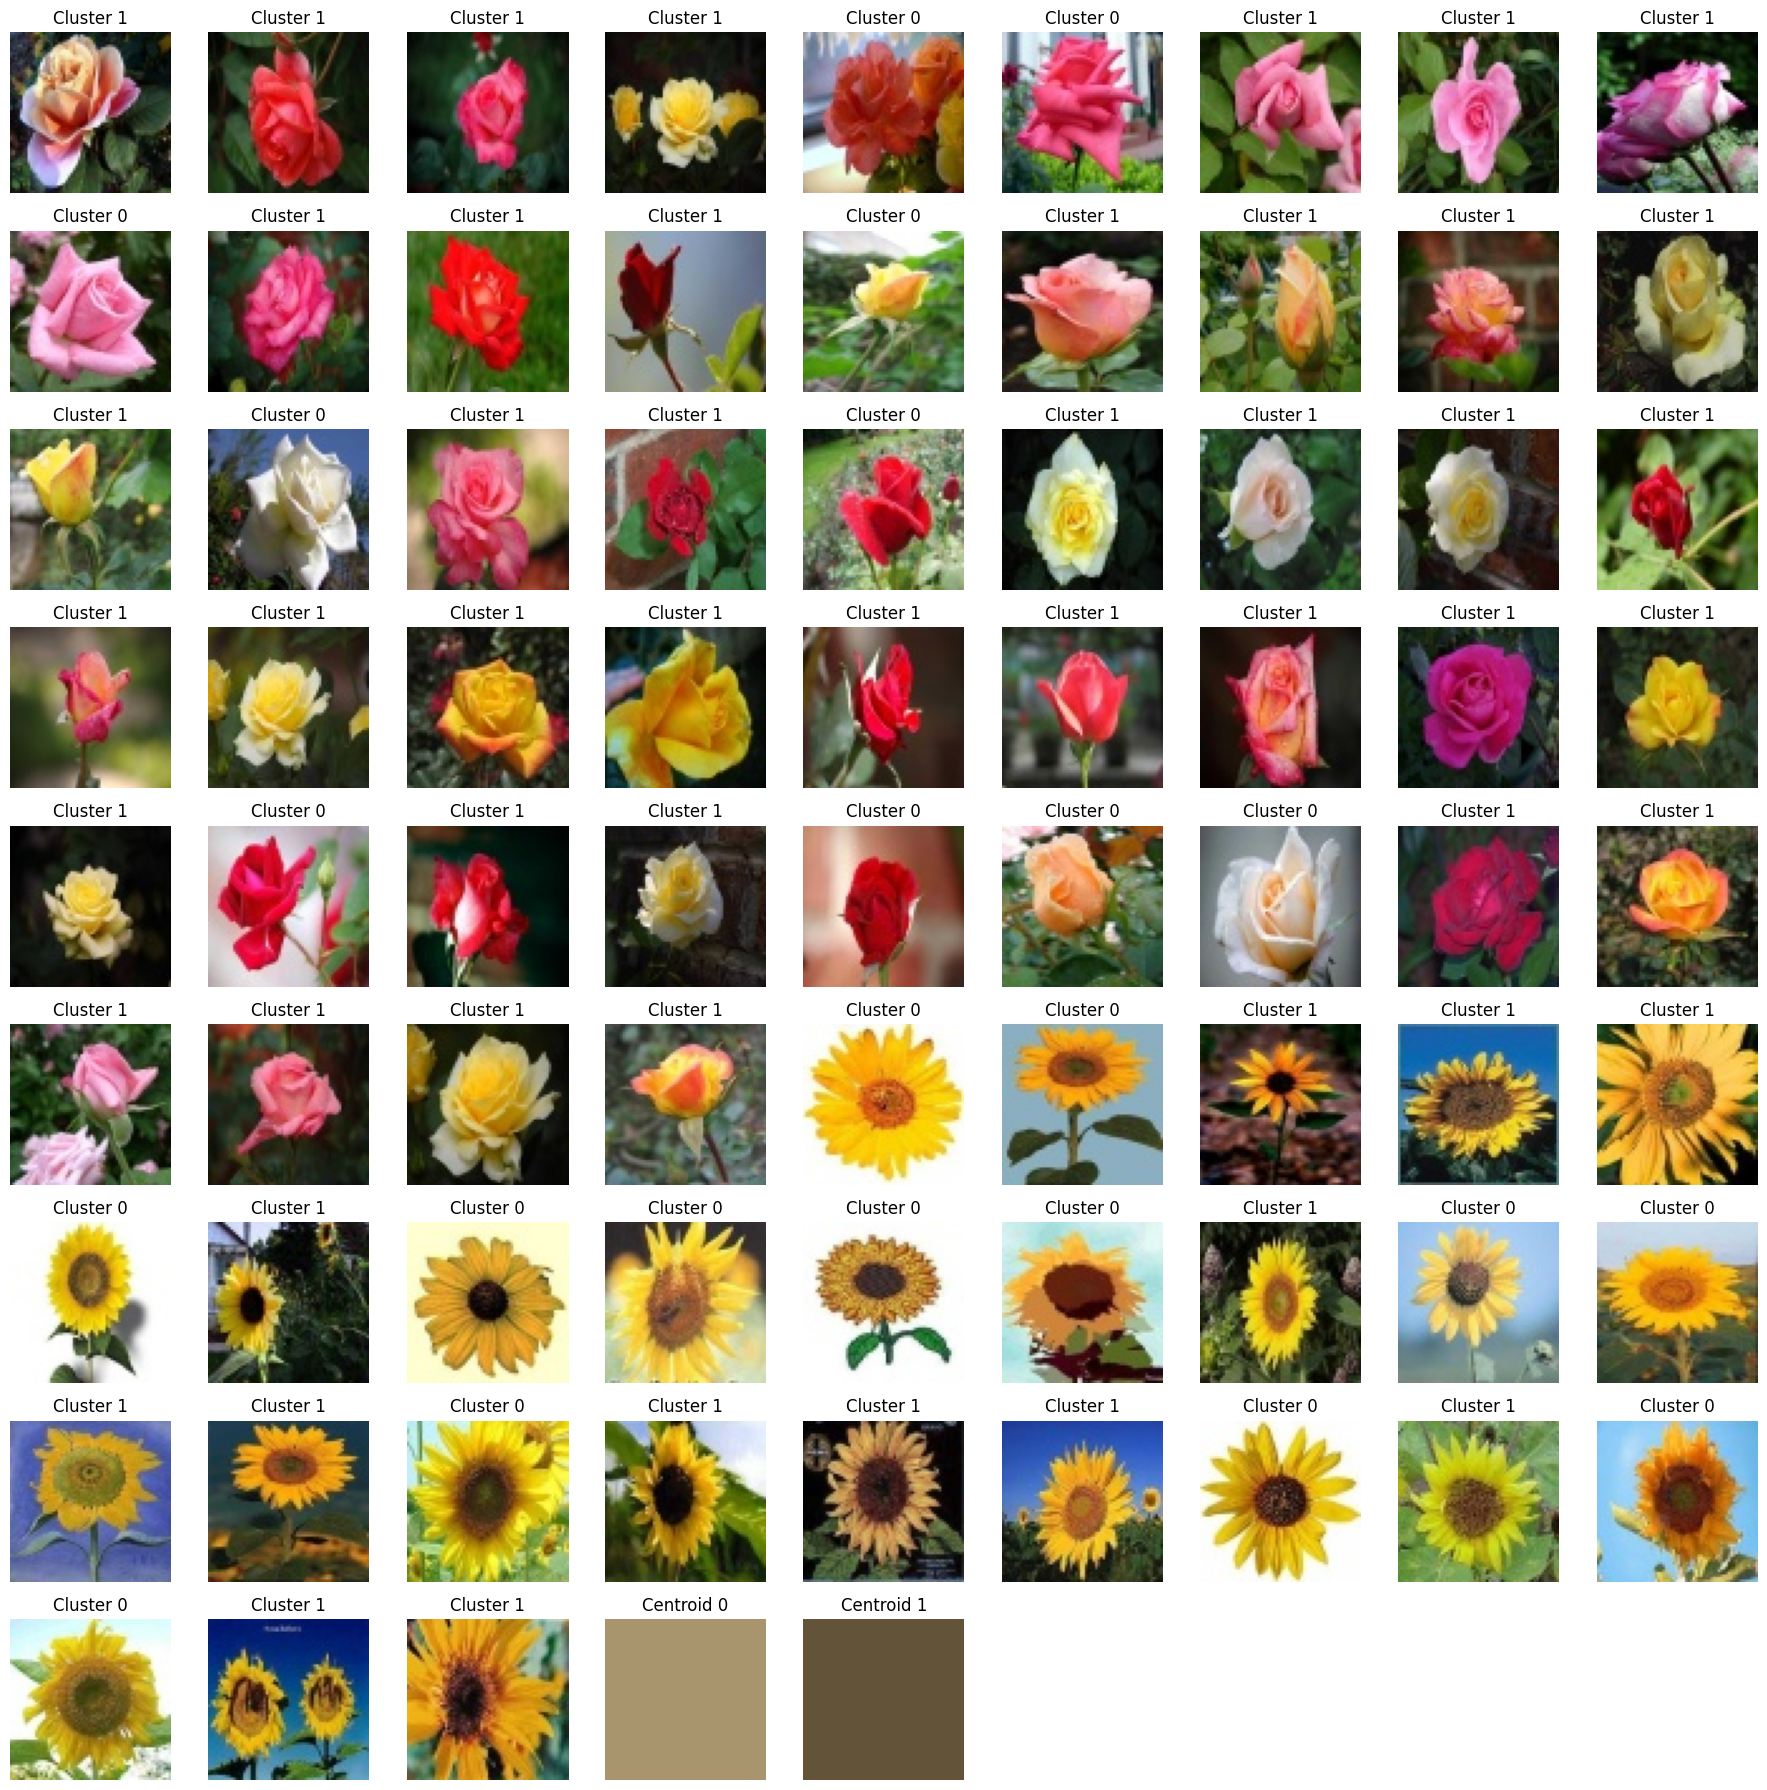

In [ ]:
from PIL import Image
import numpy as np
import os
from sklearn.cluster import KMeans
import cv2
import matplotlib.pyplot as plt

def get_image_features(image_path):
    image = Image.open(image_path)
    image_data = np.array(image)

    # Hitung nilai rata-rata RGB
    avg_rgb = image_data.mean(axis=(0, 1))
     # Hitung nilai min dan max RGB
    min_rgb = image_data.min(axis=(0, 1))
    max_rgb = image_data.max(axis=(0, 1))

    # Mengonversi gambar ke grayscale
    gray_image = cv2.cvtColor(image_data, cv2.COLOR_RGB2GRAY)

    # Menerapkan deteksi tepi Canny
    edges = cv2.Canny(gray_image, 50, 150, apertureSize=3)

    # Menemukan posisi x dan y dari tepi yang terdeteksi
    y_positions, x_positions = np.where(edges != 0)

    # Hitung rata-rata posisi x dan y jika ada tepi yang terdeteksi
    avg_x = np.mean(x_positions) if len(x_positions) > 0 else 0
    avg_y = np.mean(y_positions) if len(y_positions) > 0 else 0
     # Hitung min dan max posisi x dan y jika ada tepi yang terdeteksi
    min_x, max_x = (np.min(x_positions), np.max(x_positions)) if len(x_positions) > 0 else (0, 0)
    min_y, max_y = (np.min(y_positions), np.max(y_positions)) if len(y_positions) > 0 else (0, 0)

    return np.array([avg_rgb[0], avg_rgb[1], avg_rgb[2], avg_x, avg_y, min_rgb[0], min_rgb[1], min_rgb[2], max_rgb[0], max_rgb[1], max_rgb[2], min_x, max_x, min_y, max_y])

def get_folder_features(folder_path):
    image_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.jpg')]
    features = np.array([get_image_features(path) for path in image_paths])
    return features.mean(axis=0)

# Folder yang berisi gambar bunga mawar dan matahari
rose_folder = '/content/drive/MyDrive/Colab Notebooks/mawar'
sunflower_folder = '/content/drive/MyDrive/Colab Notebooks/sunflower'

# Hitung fitur rata-rata untuk bunga mawar dan matahari
rose_features = get_folder_features(rose_folder)
sunflower_features = get_folder_features(sunflower_folder)

# Initial centroids untuk K-Means
initial_centroids = np.array([rose_features, sunflower_features])

# Tampilkan centroid awal dengan nilai rata-rata RGB, X, dan Y
print("Initial Centroids:")
print(f"Rose Avg RGB-Edge%: R={rose_features[0]}, G={rose_features[1]}, B={rose_features[2]}, Avg_x={rose_features[3]}, Avg_y={rose_features[4]}, min_R={rose_features[5]},min_G={rose_features[6]},min_B={rose_features[7]},max_R={rose_features[8]}")
print(f"Sunflower Avg RGB-Edge%: R={sunflower_features[0]}, G={sunflower_features[1]}, B={sunflower_features[2]},  Avg_x={sunflower_features[3]}")

# Klasterisasi gambar dalam folder test
test_folder = '/content/drive/MyDrive/Colab Notebooks/test'
test_image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith('.jpg')]
test_features = np.array([get_image_features(path) for path in test_image_paths])

kmeans = KMeans(n_clusters=2, init=initial_centroids, n_init=1)
kmeans.fit(test_features)
labels = kmeans.labels_

# Print hasil klasterisasi
for label, image_path in zip(labels, test_image_paths):
    print(f"{os.path.basename(image_path)}: Cluster {label}")

# Tampilkan centroid akhir
print("Final Centroids:")
print(kmeans.cluster_centers_)

# Visualisasi hasil klasterisasi
def plot_clusters(test_image_paths, labels, centroids):
    num_images = len(test_image_paths)
    num_centroids = centroids.shape[0]
    total_plots = num_images + num_centroids
    grid_size = int(np.ceil(np.sqrt(total_plots)))

    plt.figure(figsize=(grid_size * 2, grid_size * 2))

    # Plot setiap gambar dengan label klaster
    for i, image_path in enumerate(test_image_paths):
        img = Image.open(image_path)
        img.thumbnail((100, 100))
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(img)
        plt.title(f"Cluster {labels[i]}")
        plt.axis('off')

    # Plot centroid
    for i, centroid in enumerate(centroids):
        plt.subplot(grid_size, grid_size, num_images + i + 1)
        centroid_img = np.zeros((100, 100, 3), dtype=np.uint8)
        centroid_img[:, :, 0] = centroid[0]
        centroid_img[:, :, 1] = centroid[1]
        centroid_img[:, :, 2] = centroid[2]
        plt.imshow(centroid_img)
        plt.title(f"Centroid {i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_clusters(test_image_paths, labels, kmeans.cluster_centers_)


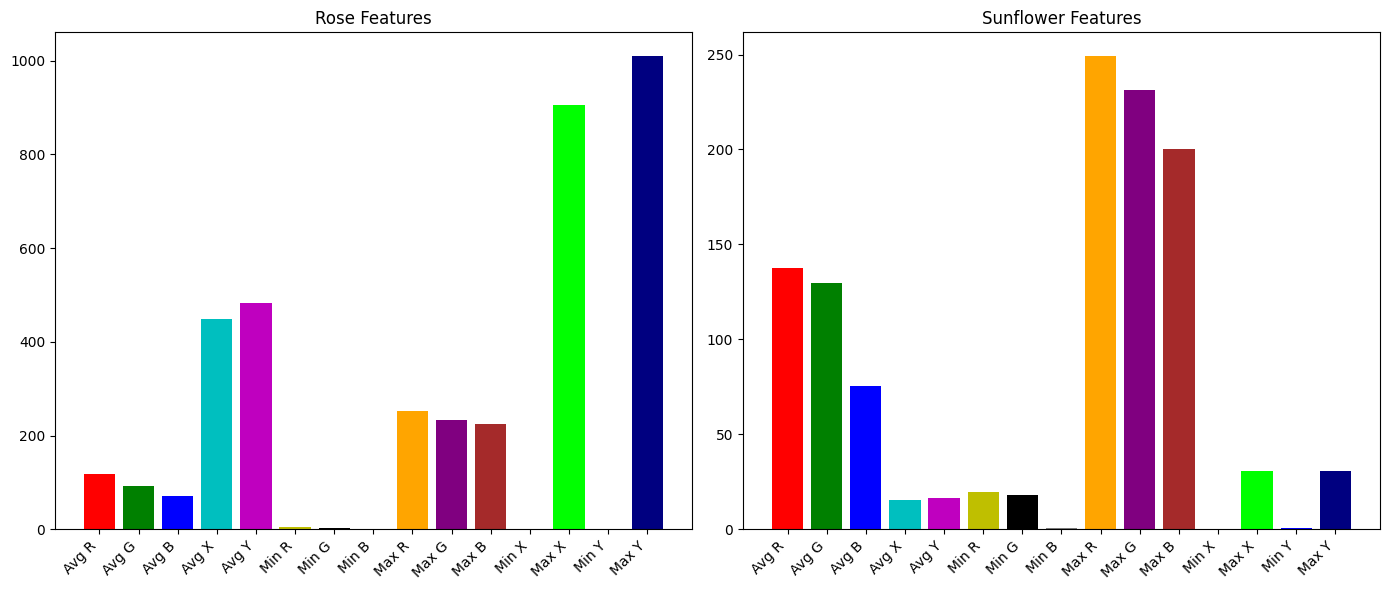

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Membuat DataFrame untuk menyimpan fitur dan hasil klasterisasi
df_test_images = pd.DataFrame(test_features, columns=['Avg R', 'Avg G', 'Avg B', 'Avg X', 'Avg Y','Min R', 'Min G', 'Min B', 'Max R', 'Max G', 'Max B', 'Min X', 'Max X', 'Min Y', 'Max Y'])
df_test_images['Filename'] = [os.path.basename(path) for path in test_image_paths]
df_test_images['Cluster'] = labels

# Membuat DataFrame untuk menyimpan centroid awal dan akhir
df_centroids = pd.DataFrame(np.vstack([initial_centroids, kmeans.cluster_centers_]),
                            columns=['Avg R', 'Avg G', 'Avg B', 'Avg X', 'Avg Y','Min R', 'Min G', 'Min B', 'Max R', 'Max G', 'Max B', 'Min X', 'Max X', 'Min Y', 'Max Y'],
                            index=['Initial Rose', 'Initial Sunflower', 'Final Rose', 'Final Sunflower'])

# Menyimpan DataFrame ke dalam file Excel
with pd.ExcelWriter('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/flower_clustering_results.xlsx') as writer:
    df_test_images.to_excel(writer, sheet_name='Test Image Features', index=False)
    df_centroids.to_excel(writer, sheet_name='Centroids', index=True)

plt.figure(figsize=(14, 6))  # Sesuaikan ukuran gambar

# Grafik untuk fitur mawar
plt.subplot(1, 2, 1)
bars = plt.bar(['Avg R', 'Avg G', 'Avg B', 'Avg X', 'Avg Y', 'Min R', 'Min G', 'Min B', 'Max R', 'Max G', 'Max B', 'Min X', 'Max X', 'Min Y', 'Max Y'], rose_features, color=['r', 'g', 'b', 'c', 'm', 'y', 'k', 'grey', 'orange', 'purple', 'brown', 'pink', 'lime', 'blue', 'navy'])
plt.title('Rose Features')
plt.xticks(rotation=45, ha="right")  # Memutar label sumbu x

# Grafik untuk fitur matahari
plt.subplot(1, 2, 2)
bars = plt.bar(['Avg R', 'Avg G', 'Avg B', 'Avg X', 'Avg Y', 'Min R', 'Min G', 'Min B', 'Max R', 'Max G', 'Max B', 'Min X', 'Max X', 'Min Y', 'Max Y'], sunflower_features, color=['r', 'g', 'b', 'c', 'm', 'y', 'k', 'grey', 'orange', 'purple', 'brown', 'pink', 'lime', 'blue', 'navy'])
plt.title('Sunflower Features')
plt.xticks(rotation=45, ha="right")  # Memutar label sumbu x

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/flower_features.png')
plt.show()




In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

def print_distances(features, centroids, centroid_labels):
    distances = euclidean_distances(features, centroids)
    for i, image_path in enumerate(test_image_paths):
        print(f"{os.path.basename(image_path)} distances:")
        for centroid_index, label in enumerate(centroid_labels):
            print(f"  to {label} centroid: {distances[i, centroid_index]}")

# Hitung dan tampilkan jarak dari gambar test ke initial centroids
print("Distances from Test Images to Initial Centroids:")
print_distances(test_features, initial_centroids, ['Rose', 'Sunflower'])

# Hitung dan tampilkan jarak dari gambar test ke final centroids
print("\nDistances from Test Images to Final Centroids:")
final_centroids = kmeans.cluster_centers_
print_distances(test_features, final_centroids, ['Rose', 'Sunflower'])


Distances from Test Images to Initial Centroids:
Rose  (41).jpg distances:
  to Rose centroid: 1409.7561197522652
  to Sunflower centroid: 99.10768506520407
Rose  (47).jpg distances:
  to Rose centroid: 1413.8813232948457
  to Sunflower centroid: 147.79903582761867
Rose  (27).jpg distances:
  to Rose centroid: 1412.6566072607923
  to Sunflower centroid: 150.26588094741132
Rose  (16).jpg distances:
  to Rose centroid: 1412.6910869676647
  to Sunflower centroid: 119.1129095357486
Rose  (10).jpg distances:
  to Rose centroid: 1410.0264992633493
  to Sunflower centroid: 88.54178116047083
Rose  (23).jpg distances:
  to Rose centroid: 1409.749222129431
  to Sunflower centroid: 94.17692322729198
Rose  (46).jpg distances:
  to Rose centroid: 1408.3335561057604
  to Sunflower centroid: 79.06583109303921
Rose  (5).jpg distances:
  to Rose centroid: 1409.1256243408832
  to Sunflower centroid: 95.85538397430756
Rose  (45).jpg distances:
  to Rose centroid: 1408.7658987707825
  to Sunflower centroi

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances
import pandas as pd

def get_distance_dataframe(features, centroids, centroid_labels, image_paths):
    distances = euclidean_distances(features, centroids)
    data = []
    for i, image_path in enumerate(image_paths):
        row = {'Filename': os.path.basename(image_path)}
        for centroid_index, label in enumerate(centroid_labels):
            row[f'Distance to {label} Centroid'] = distances[i, centroid_index]
        data.append(row)
    return pd.DataFrame(data)

# Hitung jarak dari gambar test ke initial centroids
df_distances_initial = get_distance_dataframe(test_features, initial_centroids, ['Rose', 'Sunflower'], test_image_paths)

# Hitung jarak dari gambar test ke final centroids
final_centroids = kmeans.cluster_centers_
df_distances_final = get_distance_dataframe(test_features, final_centroids, ['Rose', 'Sunflower'], test_image_paths)

# Menyimpan informasi ke dalam file Excel
with pd.ExcelWriter('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/flower_clustering_distances.xlsx') as writer:
    df_distances_initial.to_excel(writer, sheet_name='Distances to Initial Centroids', index=False)
    df_distances_final.to_excel(writer, sheet_name='Distances to Final Centroids', index=False)


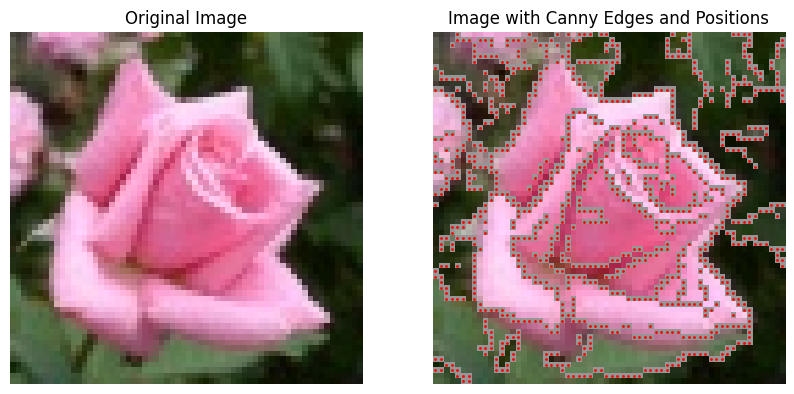

Some detected edge positions:
x: 4, y: 0
x: 17, y: 0
x: 22, y: 0
x: 24, y: 0
x: 26, y: 0
x: 27, y: 0
x: 28, y: 0
x: 30, y: 0
x: 31, y: 0
x: 43, y: 0
x: 46, y: 0
x: 54, y: 0
x: 55, y: 0
x: 56, y: 0
x: 57, y: 0
x: 4, y: 1
x: 5, y: 1
x: 6, y: 1
x: 8, y: 1
x: 9, y: 1
x: 10, y: 1
x: 13, y: 1
x: 14, y: 1
x: 15, y: 1
x: 16, y: 1
x: 18, y: 1
x: 21, y: 1
x: 25, y: 1
x: 26, y: 1
x: 32, y: 1
x: 42, y: 1
x: 45, y: 1
x: 46, y: 1
x: 57, y: 1
x: 63, y: 1
x: 3, y: 2
x: 7, y: 2
x: 10, y: 2
x: 13, y: 2
x: 19, y: 2
x: 20, y: 2
x: 22, y: 2
x: 24, y: 2
x: 31, y: 2
x: 32, y: 2
x: 33, y: 2
x: 42, y: 2
x: 46, y: 2
x: 56, y: 2
x: 57, y: 2
x: 62, y: 2
x: 63, y: 2
x: 7, y: 3
x: 15, y: 3
x: 20, y: 3
x: 24, y: 3
x: 31, y: 3
x: 33, y: 3
x: 42, y: 3
x: 44, y: 3
x: 46, y: 3
x: 56, y: 3
x: 62, y: 3
x: 7, y: 4
x: 8, y: 4
x: 9, y: 4
x: 10, y: 4
x: 11, y: 4
x: 15, y: 4
x: 20, y: 4
x: 23, y: 4
x: 24, y: 4
x: 33, y: 4
x: 42, y: 4
x: 43, y: 4
x: 44, y: 4
x: 45, y: 4
x: 46, y: 4
x: 56, y: 4
x: 57, y: 4
x: 62, y: 4
x: 7, y: 5

In [ ]:
def detect_edges_and_positions_with_canny(image_path):
    image = cv2.imread(image_path)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray_image, 50, 150, apertureSize=3)

    # Menemukan posisi x dan y dari tepi yang terdeteksi
    y_positions, x_positions = np.where(edges != 0)

    # Menandai tepi pada gambar asli dengan warna abu-abu
    image_with_edges = image.copy()
    image_with_edges[edges != 0] = [150, 150, 150]

    return image_with_edges, x_positions, y_positions

image_path = '/content/drive/MyDrive/Colab Notebooks/test/Rose  (21).jpg'
image_with_edges, x_positions, y_positions = detect_edges_and_positions_with_canny(image_path)

# Menampilkan gambar asli dan gambar dengan tepi yang terdeteksi
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(image_with_edges, cv2.COLOR_BGR2RGB))
plt.scatter(x_positions, y_positions, s=1, c='red')  # Menandai posisi tepi dengan titik merah
plt.title('Image with Canny Edges and Positions')
plt.axis('off')

plt.show()

# Print beberapa posisi x dan y dari tepi yang terdeteksi
print('Some detected edge positions:')
for x, y in zip(x_positions[:100], y_positions[:100]):  # Hanya menampilkan 10 posisi pertama untuk contoh
    print(f'x: {x}, y: {y}')


In [ ]:
pakai panjang line

In [ ]:
from PIL import Image
import numpy as np
import os
from sklearn.cluster import KMeans
import cv2

def get_image_features(image_path):
    image = Image.open(image_path)
    image_data = np.array(image)

    # Hitung nilai rata-rata RGB
    avg_rgb = image_data.mean(axis=(0, 1))
     # Hitung nilai min dan max RGB
    min_rgb = image_data.min(axis=(0, 1))
    max_rgb = image_data.max(axis=(0, 1))

    # Mengonversi gambar ke grayscale
    gray_image = cv2.cvtColor(image_data, cv2.COLOR_RGB2GRAY)

    # Menerapkan deteksi tepi Canny
    edges = cv2.Canny(gray_image, 50, 150, apertureSize=3)

    # Menemukan posisi x dan y dari tepi yang terdeteksi
    y_positions, x_positions = np.where(edges != 0)

    # Hitung rata-rata posisi x dan y jika ada tepi yang terdeteksi
    avg_x = np.mean(x_positions) if len(x_positions) > 0 else 0
    avg_y = np.mean(y_positions) if len(y_positions) > 0 else 0
     # Hitung min dan max posisi x dan y jika ada tepi yang terdeteksi
    min_x, max_x = (np.min(x_positions), np.max(x_positions)) if len(x_positions) > 0 else (0, 0)
    min_y, max_y = (np.min(y_positions), np.max(y_positions)) if len(y_positions) > 0 else (0, 0)

    # Hitung panjang garis x dan y
    length_x = np.max(x_positions) - np.min(x_positions) if len(x_positions) > 0 else 0
    length_y = np.max(y_positions) - np.min(y_positions) if len(y_positions) > 0 else 0

    return np.array([avg_rgb[0], avg_rgb[1], avg_rgb[2], avg_x, avg_y, min_rgb[0], min_rgb[1], min_rgb[2], max_rgb[0], max_rgb[1], max_rgb[2], length_x, length_y, min_x, max_x, min_y, max_y])

def get_folder_features(folder_path):
    image_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.jpg')]
    features = np.array([get_image_features(path) for path in image_paths])
    return features.mean(axis=0)

# Folder yang berisi gambar bunga mawar dan matahari
rose_folder = '/content/drive/MyDrive/Colab Notebooks/mawar'
sunflower_folder = '/content/drive/MyDrive/Colab Notebooks/sunflower'

# Hitung fitur rata-rata untuk bunga mawar dan matahari
rose_features = get_folder_features(rose_folder)
sunflower_features = get_folder_features(sunflower_folder)

# Initial centroids untuk K-Means
initial_centroids = np.array([rose_features, sunflower_features])

# Tampilkan centroid awal dengan nilai rata-rata RGB, X, dan Y
print("Initial Centroids:")
print(f"Rose Avg RGB-Edge%: R={rose_features[0]}, G={rose_features[1]}, B={rose_features[2]}, Avg_x={rose_features[3]}, Avg_y={rose_features[4]}, min_R={rose_features[5]},min_G={rose_features[6]},min_B={rose_features[7]},max_R={rose_features[8]}")
print(f"Sunflower Avg RGB-Edge%: R={sunflower_features[0]}, G={sunflower_features[1]}, B={sunflower_features[2]},  Avg_x={sunflower_features[3]}")

# Klasterisasi gambar dalam folder test
test_folder = '/content/drive/MyDrive/Colab Notebooks/test'
test_image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith('.jpg')]
test_features = np.array([get_image_features(path) for path in test_image_paths])

kmeans = KMeans(n_clusters=2, init=initial_centroids, n_init=1)
kmeans.fit(test_features)
labels = kmeans.labels_

# Print hasil klasterisasi
for label, image_path in zip(labels, test_image_paths):
    print(f"{os.path.basename(image_path)}: Cluster {label}")

# Tampilkan centroid akhir
print("Final Centroids:")
print(kmeans.cluster_centers_)


Initial Centroids:
Rose Avg RGB-Edge%: R=118.74270459339364, G=91.43413559628719, B=70.02819671117797, Avg_x=449.2544519264542, Avg_y=483.6250272655019, min_R=4.304347826086956,min_G=3.1055900621118013,min_B=0.08695652173913043,max_R=252.70807453416148
Sunflower Avg RGB-Edge%: R=137.52192071143617, G=129.5948789339539, B=75.42100232712765,  Avg_x=15.465777960656705
Rose  (41).jpg: Cluster 1
Rose  (47).jpg: Cluster 1
Rose  (27).jpg: Cluster 1
Rose  (16).jpg: Cluster 1
Rose  (10).jpg: Cluster 0
Rose  (23).jpg: Cluster 0
Rose  (46).jpg: Cluster 1
Rose  (5).jpg: Cluster 1
Rose  (45).jpg: Cluster 1
Rose  (21).jpg: Cluster 0
Rose  (4).jpg: Cluster 1
Rose  (33).jpg: Cluster 1
Rose  (37).jpg: Cluster 1
Rose  (44).jpg: Cluster 0
Rose  (20).jpg: Cluster 1
Rose  (22).jpg: Cluster 1
Rose  (14).jpg: Cluster 1
Rose  (40).jpg: Cluster 1
Rose  (26).jpg: Cluster 1
Rose  (17).jpg: Cluster 0
Rose  (31).jpg: Cluster 1
Rose  (28).jpg: Cluster 1
Rose  (15).jpg: Cluster 0
Rose  (38).jpg: Cluster 1
Rose  (3).

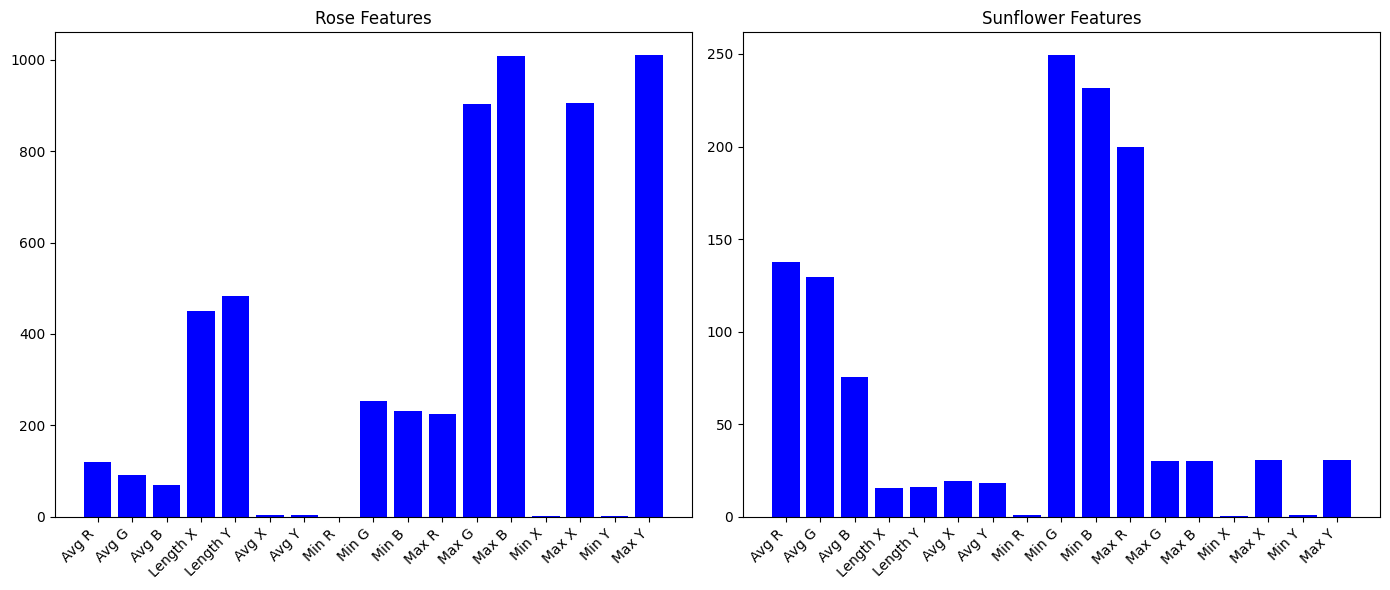

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Membuat DataFrame untuk menyimpan fitur dan hasil klasterisasi
df_test_images = pd.DataFrame(test_features, columns=['Avg R', 'Avg G', 'Avg B','Length X', 'Length Y', 'Avg X', 'Avg Y','Min R', 'Min G', 'Min B', 'Max R', 'Max G', 'Max B', 'Min X', 'Max X', 'Min Y', 'Max Y'])
df_test_images['Filename'] = [os.path.basename(path) for path in test_image_paths]
df_test_images['Cluster'] = labels

# Membuat DataFrame untuk menyimpan centroid awal dan akhir
df_centroids = pd.DataFrame(np.vstack([initial_centroids, kmeans.cluster_centers_]),
                            columns=['Avg R', 'Avg G', 'Avg B','Length X', 'Length Y', 'Avg X', 'Avg Y','Min R', 'Min G', 'Min B', 'Max R', 'Max G', 'Max B', 'Min X', 'Max X', 'Min Y', 'Max Y'],
                            index=['Initial Rose', 'Initial Sunflower', 'Final Rose', 'Final Sunflower'])

# Menyimpan DataFrame ke dalam file Excel
with pd.ExcelWriter('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/flower_clustering_results.xlsx') as writer:
    df_test_images.to_excel(writer, sheet_name='Test Image Features', index=False)
    df_centroids.to_excel(writer, sheet_name='Centroids', index=True)


plt.figure(figsize=(14, 6))  # Sesuaikan ukuran gambar

# Grafik untuk fitur mawar
plt.subplot(1, 2, 1)
bars = plt.bar(['Avg R', 'Avg G', 'Avg B','Length X', 'Length Y', 'Avg X', 'Avg Y','Min R', 'Min G', 'Min B', 'Max R', 'Max G', 'Max B', 'Min X', 'Max X', 'Min Y', 'Max Y'],
               rose_features, color='blue')  # Menggunakan satu warna (biru)
plt.title('Rose Features')
plt.xticks(rotation=45, ha="right")  # Memutar label sumbu x

# Grafik untuk fitur matahari
plt.subplot(1, 2, 2)
bars = plt.bar(['Avg R', 'Avg G', 'Avg B','Length X', 'Length Y', 'Avg X', 'Avg Y','Min R', 'Min G', 'Min B', 'Max R', 'Max G', 'Max B', 'Min X', 'Max X', 'Min Y', 'Max Y'],
               sunflower_features, color='blue')  # Menggunakan satu warna (biru)
plt.title('Sunflower Features')
plt.xticks(rotation=45, ha="right")  # Memutar label sumbu x

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/flower_features.png')
plt.show()


In [ ]:
from PIL import Image
import numpy as np

# Load the image using PIL
image = Image.open('/content/drive/MyDrive/Colab Notebooks/mawar.jpg')

# Convert the image to RGB
image_rgb = image.convert('RGB')

# Convert the image to a numpy array
image_array = np.array(image_rgb)

# Calculate the average RGB values
average_rgb = image_array.mean(axis=(0, 1))
average_r = average_rgb[0]
average_g = average_rgb[1]
average_b = average_rgb[2]

print(f'Average Red: {average_r}')
print(f'Average Green: {average_g}')
print(f'Average Blue: {average_b}')

# Loop through each pixel in the image
for i in range(image_array.shape[0]):  # For every row
    for j in range(image_array.shape[1]):  # For every column
        r, g, b = image_array[i, j]
        print(f'Pixel ({i},{j}): Red: {r}, Green: {g}, Blue: {b}')

Average Red: 202.36
Average Green: 184.8
Average Blue: 168.68
Pixel (0,0): Red: 252, Green: 255, Blue: 237
Pixel (0,1): Red: 250, Green: 254, Blue: 231
Pixel (0,2): Red: 171, Green: 170, Blue: 142
Pixel (0,3): Red: 244, Green: 247, Blue: 220
Pixel (0,4): Red: 251, Green: 255, Blue: 246
Pixel (1,0): Red: 255, Green: 250, Blue: 236
Pixel (1,1): Red: 238, Green: 222, Blue: 206
Pixel (1,2): Red: 120, Green: 98, Blue: 77
Pixel (1,3): Red: 237, Green: 220, Blue: 200
Pixel (1,4): Red: 254, Green: 254, Blue: 242
Pixel (2,0): Red: 253, Green: 205, Blue: 201
Pixel (2,1): Red: 91, Green: 38, Blue: 32
Pixel (2,2): Red: 127, Green: 60, Blue: 52
Pixel (2,3): Red: 77, Green: 22, Blue: 15
Pixel (2,4): Red: 229, Green: 212, Blue: 205
Pixel (3,0): Red: 255, Green: 235, Blue: 229
Pixel (3,1): Red: 137, Green: 90, Blue: 82
Pixel (3,2): Red: 108, Green: 52, Blue: 39
Pixel (3,3): Red: 142, Green: 96, Blue: 83
Pixel (3,4): Red: 250, Green: 237, Blue: 228
Pixel (4,0): Red: 246, Green: 251, Blue: 228
Pixel (4,

In [ ]:
# Define the RGB matrix
rgb_matrix = [
    [(252, 255, 237), (250, 254, 231), (171, 170, 142), (244, 247, 220), (251, 255, 246)],
    [(255, 250, 236), (238, 222, 206), (120, 98, 77),   (237, 220, 200), (254, 254, 242)],
    [(253, 205, 201), (91, 38, 32),    (127, 60, 52),   (77, 22, 15),    (229, 212, 205)],
    [(255, 235, 229), (137, 90, 82),   (108, 52, 39),   (142, 96, 83),   (250, 237, 228)],
    [(246, 251, 228), (200, 206, 178), (186, 192, 156), (237, 244, 211), (249, 255, 241)]
]

# Convert the RGB matrix to a grayscale matrix using the average method
grayscale_matrix = [
    [round((r + g + b) / 3) for r, g, b in row]
    for row in rgb_matrix
]

# Output the grayscale matrix
for row in grayscale_matrix:
    print(row)


[248, 245, 161, 237, 251]
[247, 222, 98, 219, 250]
[220, 54, 80, 38, 215]
[240, 103, 66, 107, 238]
[242, 195, 178, 231, 248]


In [ ]:
from PIL import Image

# Load the image
image = Image.open('/content/drive/MyDrive/Colab Notebooks/mawar.jpg')

# Convert the image to grayscale
gray_image = image.convert('L')

# Save or display the grayscale image
gray_image.save('/content/drive/MyDrive/Colab Notebooks/mawar_gray_image.jpg')
gray_image.show()


In [ ]:
import cv2
import numpy as np

# Load the image in grayscale mode
image = cv2.imread('/content/drive/MyDrive/Colab Notebooks/mawar.jpg', 0)

# Apply Canny edge detection
edges = cv2.Canny(image, threshold1=50, threshold2=150)

# Print the resulting edge matrix
print("Edge matrix from Canny:")
print(edges)

# Get the positions of the edge pixels
y_positions, x_positions = np.where(edges == 255)

# Print the positions
print("X positions of edges:", x_positions)
print("Y positions of edges:", y_positions)


Edge matrix from Canny:
[[  0 255   0 255   0]
 [  0 255 255 255   0]
 [  0 255   0 255   0]
 [  0 255 255 255   0]
 [  0 255   0 255   0]]
X positions of edges: [1 3 1 2 3 1 3 1 2 3 1 3]
Y positions of edges: [0 0 1 1 1 2 2 3 3 3 4 4]


In [ ]:
import cv2
import numpy as np

# Load the image in grayscale mode
image = cv2.imread('/content/drive/MyDrive/Colab Notebooks/mawar.jpg', 0)

# Apply Canny edge detection
edges = cv2.Canny(image, threshold1=50, threshold2=150)

# Print the resulting edge matrix
print("Edge matrix from Canny:")
print(edges)

# Get the positions of the edge pixels
y_positions, x_positions = np.where(edges == 255)

# Increment positions to start from 1 instead of 0
x_positions += 1
y_positions += 1

# Print the positions
print("X positions of edges:", x_positions)
print("Y positions of edges:", y_positions)

Edge matrix from Canny:
[[  0 255   0 255   0]
 [  0 255 255 255   0]
 [  0 255   0 255   0]
 [  0 255 255 255   0]
 [  0 255   0 255   0]]
X positions of edges: [2 4 2 3 4 2 4 2 3 4 2 4]
Y positions of edges: [1 1 2 2 2 3 3 4 4 4 5 5]


In [ ]:
pakai gambar CIFAR 10

In [ ]:
from PIL import Image
import numpy as np
import os
from sklearn.cluster import KMeans
import cv2

def get_image_features(image_path):
    image = Image.open(image_path)
    image_data = np.array(image)

    # Hitung nilai rata-rata RGB
    avg_rgb = image_data.mean(axis=(0, 1))
     # Hitung nilai min dan max RGB
    min_rgb = image_data.min(axis=(0, 1))
    max_rgb = image_data.max(axis=(0, 1))

    # Mengonversi gambar ke grayscale
    gray_image = cv2.cvtColor(image_data, cv2.COLOR_RGB2GRAY)

    # Menerapkan deteksi tepi Canny
    edges = cv2.Canny(gray_image, 50, 150, apertureSize=3)

    # Menemukan posisi x dan y dari tepi yang terdeteksi
    y_positions, x_positions = np.where(edges != 0)

    # Hitung rata-rata posisi x dan y jika ada tepi yang terdeteksi
    avg_x = np.mean(x_positions) if len(x_positions) > 0 else 0
    avg_y = np.mean(y_positions) if len(y_positions) > 0 else 0
     # Hitung min dan max posisi x dan y jika ada tepi yang terdeteksi
    min_x, max_x = (np.min(x_positions), np.max(x_positions)) if len(x_positions) > 0 else (0, 0)
    min_y, max_y = (np.min(y_positions), np.max(y_positions)) if len(y_positions) > 0 else (0, 0)

    # Hitung panjang garis x dan y
    length_x = np.max(x_positions) - np.min(x_positions) if len(x_positions) > 0 else 0
    length_y = np.max(y_positions) - np.min(y_positions) if len(y_positions) > 0 else 0

    return np.array([avg_rgb[0], avg_rgb[1], avg_rgb[2], avg_x, avg_y, min_rgb[0], min_rgb[1], min_rgb[2], max_rgb[0], max_rgb[1], max_rgb[2], length_x, length_y, min_x, max_x, min_y, max_y])

def get_folder_features(folder_path):
    image_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.png')]
    features = np.array([get_image_features(path) for path in image_paths])
    return features.mean(axis=0)

# Folder yang berisi gambar bunga mawar dan matahari
truck_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/train/truck'
airplane_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/train/airplane'
automobile_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/train/automobile'
bird_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/train/bird'
cat_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/train/cat'
deer_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/train/deer'
dog_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/train/dog'
frog_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/train/frog'
horse_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/train/horse'
ship_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/train/ship'

# Hitung fitur rata-rata untuk bunga mawar dan matahari
truck_features = get_folder_features(truck_folder)
airplane_features = get_folder_features(airplane_folder)
automobile_features = get_folder_features(automobile_folder)
bird_features = get_folder_features(bird_folder)
cat_features = get_folder_features(cat_folder)
deer_features = get_folder_features(deer_folder)
dog_features = get_folder_features(dog_folder)
frog_features = get_folder_features(frog_folder)
horse_features = get_folder_features(horse_folder)
ship_features = get_folder_features(ship_folder)

# Initial centroids untuk K-Means
initial_centroids = np.array([truck_features, airplane_features,automobile_features,bird_features,cat_features,deer_features,dog_features,frog_features,horse_features,ship_features])


# Klasterisasi gambar dalam folder test
test_folder = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/test cifar'
test_image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith('.png')]
test_features = np.array([get_image_features(path) for path in test_image_paths])

kmeans = KMeans(n_clusters=10, init=initial_centroids, n_init=1)
kmeans.fit(test_features)
labels = kmeans.labels_

# Print hasil klasterisasi
for label, image_path in zip(labels, test_image_paths):
    print(f"{os.path.basename(image_path)}: Cluster {label}")

# Tampilkan centroid akhir
print("Final Centroids:")
print(kmeans.cluster_centers_)


automobile (756).png: Cluster 4
cat (768).png: Cluster 9
cat (769).png: Cluster 0
automobile (757).png: Cluster 0
truck (760).png: Cluster 8
airplane (762).png: Cluster 1
airplane (773).png: Cluster 9
ship (755).png: Cluster 2
airplane (770).png: Cluster 9
ship (737).png: Cluster 0
automobile (758).png: Cluster 0
airplane (761).png: Cluster 0
airplane (757).png: Cluster 5
airplane (768).png: Cluster 0
cat (765).png: Cluster 0
airplane (772).png: Cluster 8
cat (762).png: Cluster 6
airplane (769).png: Cluster 3
truck (758).png: Cluster 6
automobile (765).png: Cluster 9
automobile (763).png: Cluster 1
airplane (767).png: Cluster 9
ship (744).png: Cluster 0
automobile (754).png: Cluster 7
automobile (751).png: Cluster 0
automobile (759).png: Cluster 0
automobile (755).png: Cluster 9
truck (740).png: Cluster 5
airplane (756).png: Cluster 8
airplane (760).png: Cluster 3
truck (757).png: Cluster 9
ship (754).png: Cluster 3
cat (763).png: Cluster 2
automobile (753).png: Cluster 0
airplane (758

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

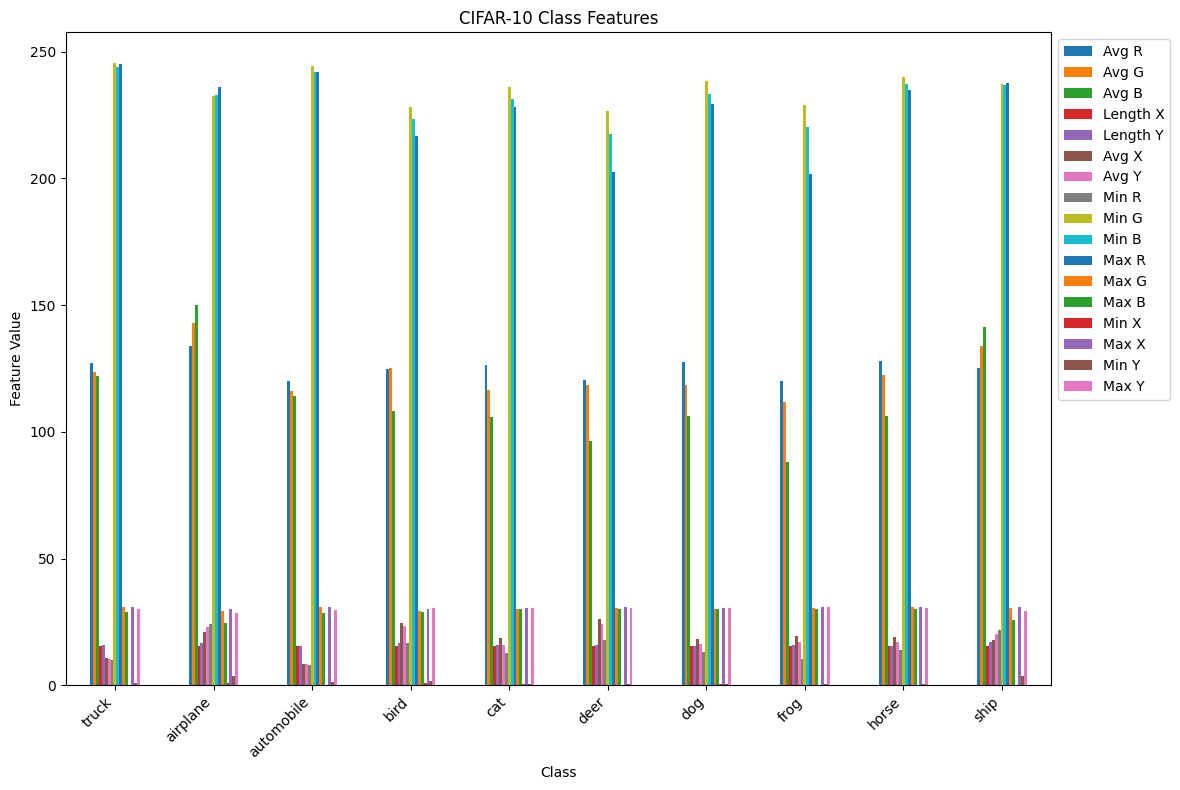

IndexError: At least one sheet must be visible

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the class feature vectors here (they should be computed before this step)
class_features = {
    'truck': truck_features,
    'airplane': airplane_features,
    'automobile': automobile_features,
    'bird': bird_features,
    'cat': cat_features,
    'deer': deer_features,
    'dog': dog_features,
    'frog': frog_features,
    'horse': horse_features,
    'ship': ship_features
}

# Create a DataFrame from the class features
df_class_features = pd.DataFrame.from_dict(class_features, orient='index')
df_class_features.columns = ['Avg R', 'Avg G', 'Avg B', 'Length X', 'Length Y', 'Avg X', 'Avg Y', 'Min R', 'Min G', 'Min B', 'Max R', 'Max G', 'Max B', 'Min X', 'Max X', 'Min Y', 'Max Y']

# Let's say you have 10 initial centroids and 10 final centroids
index_labels = ['Initial ' + cls for cls in df_class_features.index] + ['Final ' + cls for cls in df_class_features.index]

# Assuming initial_centroids and kmeans.cluster_centers_ are defined correctly and have the right shapes
# Create the DataFrame using the correct number of index labels
df_centroids = pd.DataFrame(
    np.vstack([initial_centroids, kmeans.cluster_centers_]),
    columns=df_class_features.columns,
    index=index_labels
)

# Plotting the features for each class
fig, ax = plt.subplots(figsize=(14, 8))
df_class_features.plot(kind='bar', ax=ax)
plt.title('CIFAR-10 Class Features')
plt.xticks(rotation=45, ha="right")  # Rotate the x labels for better readability
plt.xlabel('Class')
plt.ylabel('Feature Value')

# Place the legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1,1))

# Use a tight layout with a rectangle parameter to fit the plot and legend into the figure
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Save the plot to a file
plt.savefig('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/cifar10_class_features.png')

# Show the plot
plt.show()

# Save DataFrames to Excel
with pd.ExcelWriter('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/cifar10_clustering_results.xlsx') as writer:
    df_test_images.to_excel(writer, sheet_name='Test Image Features', index=False)
    df_centroids.to_excel(writer, sheet_name='Centroids', index=True)

print("Data has been saved to Excel.")


In [ ]:
from sklearn.cluster import KMeans
import numpy as np
from tensorflow.keras.datasets import mnist
import cv2

def get_image_features(image):
    # Gambar sudah dalam bentuk array grayscale
    # Hitung rata-rata intensitas
    avg_intensity = image.mean()

    # Hitung nilai min dan max intensitas
    min_intensity = image.min()
    max_intensity = image.max()

    # Menerapkan deteksi tepi Canny
    edges = cv2.Canny(image.astype(np.uint8), 50, 150, apertureSize=3)

    # Menemukan posisi x dan y dari tepi yang terdeteksi
    y_positions, x_positions = np.where(edges != 0)

    # Hitung rata-rata posisi x dan y jika ada tepi yang terdeteksi
    avg_x = np.mean(x_positions) if len(x_positions) > 0 else 0
    avg_y = np.mean(y_positions) if len(y_positions) > 0 else 0

    # Hitung panjang garis x dan y
    length_x = np.max(x_positions) - np.min(x_positions) if len(x_positions) > 0 else 0
    length_y = np.max(y_positions) - np.min(y_positions) if len(y_positions) > 0 else 0

    return np.array([avg_intensity, min_intensity, max_intensity, avg_x, avg_y, length_x, length_y])

# Memuat dataset MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Hitung fitur rata-rata untuk setiap digit 0-9
centroid_features = []
for digit in range(10):
    digit_images = x_train[y_train == digit]
    features = np.array([get_image_features(image) for image in digit_images])
    centroid_features.append(features.mean(axis=0))

# Initial centroids untuk K-Means
initial_centroids = np.array(centroid_features)

# Hitung fitur untuk gambar uji
test_features = np.array([get_image_features(image) for image in x_test])

# Klasterisasi menggunakan K-Means
kmeans = KMeans(n_clusters=10, init=initial_centroids, n_init=1)
kmeans.fit(test_features)
labels = kmeans.labels_

# Print hasil klasterisasi untuk beberapa gambar
for i in range(10):
    print(f"Image {i}: Cluster {labels[i]}")

# Tampilkan centroid akhir
print("Final Centroids:")
print(kmeans.cluster_centers_)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image 0: Cluster 7
Image 1: Cluster 3
Image 2: Cluster 1
Image 3: Cluster 2
Image 4: Cluster 5
Image 5: Cluster 1
Image 6: Cluster 5
Image 7: Cluster 5
Image 8: Cluster 3
Image 9: Cluster 6
Final Centroids:
[[ 64.96561307   0.         254.89430894  14.13737558  13.87872228
   18.42682927  19.18699187]
 [ 15.90960632   0.         254.90254237  14.04490893  13.93291009
    5.69491525  19.08898305]
 [ 44.46803705   0.         254.89462049  14.00038449  13.87981941
   16.84377303  19.05084746]
 [ 36.0564041    0.         254.88687783  14.00609231  13.91579945
   18.32669683  18.56470588]
 [ 32.11836101   0.         254.89503106  13.96559774  13.9339966
   13.55838509  19.34223602]
 [ 26.98083009   0.         254.88785047  14.01000834  13.96361317
   17.46261682  18.10864486]
 [ 38.37496278   0.         254.90627763  13.97437326  13.88779528
   13.98231653  19.25641026]
 [ 20.44740474   0.         254.90238837  13.95598726  13.99005765
   1

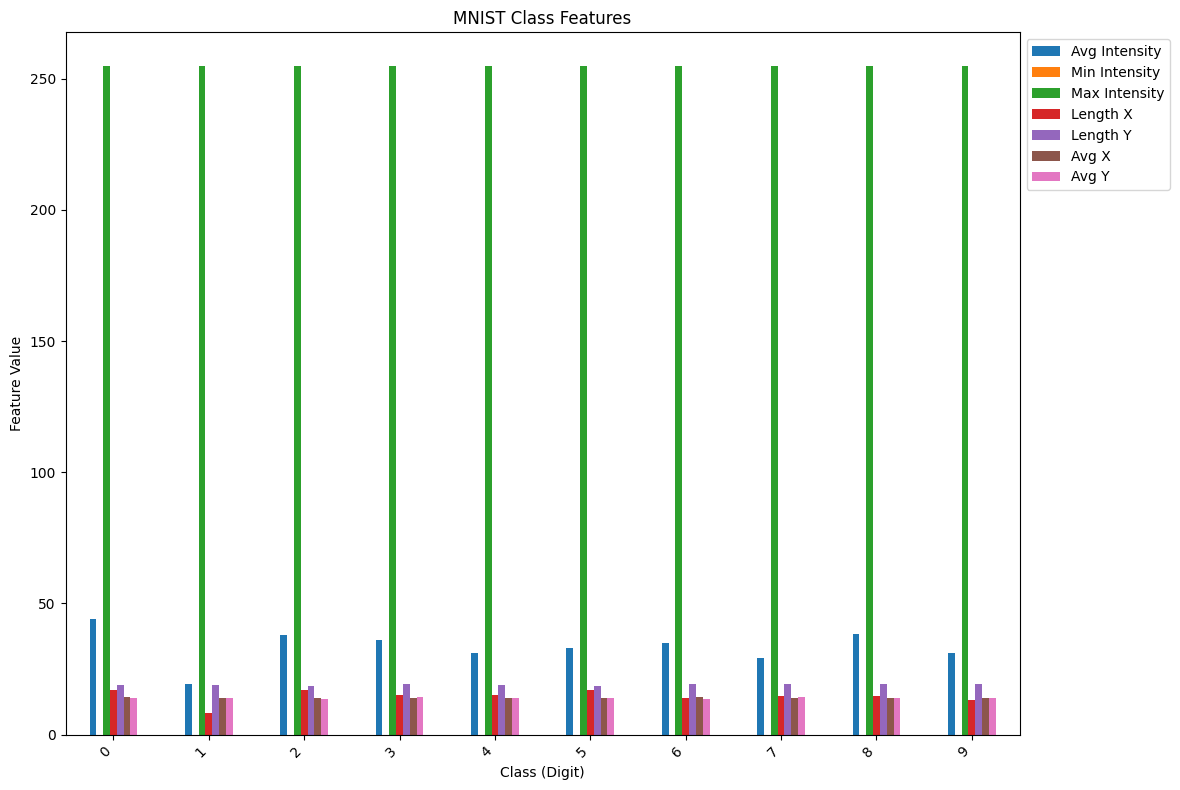

Data has been saved to Excel.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.cluster import KMeans
import cv2

# Fungsi untuk menghitung fitur dari gambar
def get_image_features(image):
    # Hitung rata-rata intensitas
    avg_intensity = image.mean()

    # Hitung nilai min dan max intensitas
    min_intensity = image.min()
    max_intensity = image.max()

    # Deteksi tepi menggunakan Canny
    edges = cv2.Canny(image.astype(np.uint8), 50, 150, apertureSize=3)

    # Temukan posisi x dan y dari tepi yang terdeteksi
    y_positions, x_positions = np.where(edges != 0)

    # Hitung rata-rata posisi x dan y jika ada tepi yang terdeteksi
    avg_x = np.mean(x_positions) if len(x_positions) > 0 else 0
    avg_y = np.mean(y_positions) if len(y_positions) > 0 else 0

    # Hitung panjang garis x dan y
    length_x = np.max(x_positions) - np.min(x_positions) if len(x_positions) > 0 else 0
    length_y = np.max(y_positions) - np.min(y_positions) if len(y_positions) > 0 else 0

    return np.array([avg_intensity, min_intensity, max_intensity, length_x, length_y, avg_x, avg_y])

# Memuat dataset MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Hitung fitur rata-rata untuk setiap digit 0-9
class_features = {}
for digit in range(10):
    digit_images = x_train[y_train == digit]
    features = np.array([get_image_features(image) for image in digit_images])
    class_features[str(digit)] = features.mean(axis=0)

# Konversi fitur kelas ke DataFrame
df_class_features = pd.DataFrame.from_dict(class_features, orient='index')
df_class_features.columns = ['Avg Intensity', 'Min Intensity', 'Max Intensity', 'Length X', 'Length Y', 'Avg X', 'Avg Y']

# Centroid awal untuk K-Means
initial_centroids = df_class_features.values

# Hitung fitur untuk gambar uji
test_features = np.array([get_image_features(image) for image in x_test])

# Klasterisasi menggunakan K-Means
kmeans = KMeans(n_clusters=10, init=initial_centroids, n_init=1)
kmeans.fit(test_features)

# Centroid akhir
final_centroids = kmeans.cluster_centers_

# Buat DataFrame untuk centroid
index_labels = ['Initial ' + str(cls) for cls in range(10)] + ['Final ' + str(cls) for cls in range(10)]
df_centroids = pd.DataFrame(
    np.vstack([initial_centroids, final_centroids]),
    columns=df_class_features.columns,
    index=index_labels
)

# Plotting fitur untuk setiap digit
fig, ax = plt.subplots(figsize=(14, 8))
df_class_features.plot(kind='bar', ax=ax)
plt.title('MNIST Class Features')
plt.xticks(rotation=45, ha="right")
plt.xlabel('Class (Digit)')
plt.ylabel('Feature Value')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/mnist_class_features.png')
plt.show()

# Simpan DataFrame ke Excel
with pd.ExcelWriter('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/mnist_clustering_results.xlsx') as writer:
    df_centroids.to_excel(writer, sheet_name='Centroids', index=True)

print("Data has been saved to Excel.")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.cluster import KMeans
import cv2

# Fungsi untuk menghitung fitur dari gambar
def get_image_features(image):
    # Hitung rata-rata intensitas
    avg_intensity = image.mean()

    # Hitung nilai min dan max intensitas
    min_intensity = image.min()
    max_intensity = image.max()

    # Deteksi tepi menggunakan Canny
    edges = cv2.Canny(image.astype(np.uint8), 50, 150, apertureSize=3)

    # Temukan posisi x dan y dari tepi yang terdeteksi
    y_positions, x_positions = np.where(edges != 0)

    # Hitung rata-rata posisi x dan y jika ada tepi yang terdeteksi
    avg_x = np.mean(x_positions) if len(x_positions) > 0 else 0
    avg_y = np.mean(y_positions) if len(y_positions) > 0 else 0

    # Hitung panjang garis x dan y
    length_x = np.max(x_positions) - np.min(x_positions) if len(x_positions) > 0 else 0
    length_y = np.max(y_positions) - np.min(y_positions) if len(y_positions) > 0 else 0

    return np.array([avg_intensity, min_intensity, max_intensity, length_x, length_y, avg_x, avg_y])

# Memuat dataset MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Hitung fitur rata-rata untuk setiap digit 0-9
class_features = {}
for digit in range(10):
    digit_images = x_train[y_train == digit]
    features = np.array([get_image_features(image) for image in digit_images])
    class_features[str(digit)] = features.mean(axis=0)

# Konversi fitur kelas ke DataFrame
df_class_features = pd.DataFrame.from_dict(class_features, orient='index')
df_class_features.columns = ['Avg Intensity', 'Min Intensity', 'Max Intensity', 'Length X', 'Length Y', 'Avg X', 'Avg Y']

# Centroid awal untuk K-Means
initial_centroids = df_class_features.values

# Hitung fitur untuk gambar uji
test_features = np.array([get_image_features(image) for image in x_test])

# Klasterisasi menggunakan K-Means
kmeans = KMeans(n_clusters=10, init=initial_centroids, n_init=1, random_state=42)
kmeans.fit(test_features)

# Centroid akhir
final_centroids = kmeans.cluster_centers_

# Buat DataFrame untuk centroid
index_labels = ['Initial ' + str(cls) for cls in range(10)] + ['Final ' + str(cls) for cls in range(10)]
df_centroids = pd.DataFrame(
    np.vstack([initial_centroids, final_centroids]),
    columns=df_class_features.columns,
    index=index_labels
)

# Membuat DataFrame untuk setiap klaster
clustered_data = {f'Cluster {i}': [] for i in range(10)}
clustered_labels = {f'Cluster {i}': [] for i in range(10)}

for idx, label in enumerate(kmeans.labels_):
    clustered_data[f'Cluster {label}'].append(test_features[idx])
    clustered_labels[f'Cluster {label}'].append(y_test[idx])  # Simpan label asli

# Simpan hasil ke Excel
with pd.ExcelWriter('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/mnist_clustering_results.xlsx') as writer:
    # Simpan centroid awal dan akhir
    df_centroids.to_excel(writer, sheet_name='Centroids', index=True)

    # Simpan data klaster dengan label asli
    for cluster_name, data in clustered_data.items():
        # Tambahkan label asli ke data klaster
        labels = clustered_labels[cluster_name]
        df_cluster = pd.DataFrame(data, columns=['Avg Intensity', 'Min Intensity', 'Max Intensity', 'Length X', 'Length Y', 'Avg X', 'Avg Y'])
        df_cluster['True Label'] = labels
        df_cluster.to_excel(writer, sheet_name=cluster_name, index=False)

print("Data has been saved to Excel.")



tambah anagka di latar

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Load the image
image_path = '/content/drive/MyDrive/Colab Notebooks/Picture1.jpg'  # Adjust the path as needed
image = cv2.imread(image_path)

# Resize the image to 10x10 pixels
dim = (2, 2)
resized_image = cv2.resize(image, dim, interpolation=cv2.INTER_AREA)

# Convert to RGB (OpenCV uses BGR by default)
image_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

# Create a blank image with the same dimensions, scaled up for better visibility
scale_factor = 50  # Scale up factor for better visibility
scaled_up_image = cv2.resize(image_rgb, (dim[0] * scale_factor, dim[1] * scale_factor), interpolation=cv2.INTER_NEAREST)

# Create a blank image with the same dimensions as the scaled-up image
blank_image = np.zeros_like(scaled_up_image)

# Define font and scale
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.6  # Adjust font scale for readability
font_color = (0, 0, 0)  # Black color
font_thickness = 2  # Increase thickness for bold font

# Loop through the resized image and add red channel pixel values to the blank image
for i in range(2):
    for j in range(2):
        r = image_rgb[i, j, 2]
        pixel_value = f'{round(r)}'
        x = j * scale_factor + 5
        y = i * scale_factor + 15
        # Draw white background for text
        cv2.rectangle(blank_image, (j * scale_factor, i * scale_factor), ((j + 1) * scale_factor, (i + 1) * scale_factor), (255, 255, 255), -1)
        # Draw black text
        cv2.putText(blank_image, pixel_value, (x, y), font, font_scale, font_color, font_thickness)

# Combine the images
combined_image = cv2.addWeighted(scaled_up_image, 0.7, blank_image, 0.3, 0)

# Display the images
plt.figure(figsize=(20, 10))

# Display resized 10x10 image
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('10x10 Resized Image')
plt.axis('off')

# Display combined image with pixel values
plt.subplot(1, 2, 2)
plt.imshow(combined_image)
plt.title('Blue Channel Values on 10x10 Image')
plt.axis('off')

plt.show()


frekuensi

In [ ]:
import numpy as np
import cv2
import pandas as pd
from matplotlib import pyplot as plt

# Load the image
image_path = '/content/drive/MyDrive/Colab Notebooks/Picture1.jpg'  # Adjust the path as needed
image = cv2.imread(image_path)

# Resize the image to 50x50 pixels
dim = (50, 50)
resized_image = cv2.resize(image, dim, interpolation=cv2.INTER_AREA)

# Convert to RGB (OpenCV uses BGR by default)
image_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

# Extract RGB channels
red_channel = image_rgb[:, :, 0].flatten()
green_channel = image_rgb[:, :, 1].flatten()
blue_channel = image_rgb[:, :, 2].flatten()

# Partition the pixel values into 6 bins
bins = 6
red_hist, red_bin_edges = np.histogram(red_channel, bins=bins, range=(0, 256))
green_hist, green_bin_edges = np.histogram(green_channel, bins=bins, range=(0, 256))
blue_hist, blue_bin_edges = np.histogram(blue_channel, bins=bins, range=(0, 256))

# Calculate CDF for each channel
red_cdf = np.cumsum(red_hist) / red_hist.sum()
green_cdf = np.cumsum(green_hist) / green_hist.sum()
blue_cdf = np.cumsum(blue_hist) / blue_hist.sum()

# Create a DataFrame to save to Excel
cdf_data = {
    'Bin Edges': red_bin_edges[:-1],
    'Red Count': red_hist,
    'Red CDF': red_cdf,
    'Green Count': green_hist,
    'Green CDF': green_cdf,
    'Blue Count': blue_hist,
    'Blue CDF': blue_cdf
}

df = pd.DataFrame(cdf_data)

# Save the DataFrame to an Excel file
output_path = '/content/drive/MyDrive/Colab Notebooks/kumpulan excel/cdf_data.xlsx'
df.to_excel(output_path, index=False)

print(f"CDF data saved to {output_path}")

# Plot the CDFs
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(red_bin_edges[:-1], red_cdf, color='red')
plt.title('Red Channel CDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('CDF')

plt.subplot(3, 1, 2)
plt.plot(green_bin_edges[:-1], green_cdf, color='green')
plt.title('Green Channel CDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('CDF')

plt.subplot(3, 1, 3)
plt.plot(blue_bin_edges[:-1], blue_cdf, color='blue')
plt.title('Blue Channel CDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('CDF')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/cdf_plots.png')
plt.show()

print("CDF plots saved to /content/drive/MyDrive/Colab Notebooks/kumpulan excel/cdf_plots.png")


In [ ]:
import numpy as np
import cv2
import pandas as pd
from matplotlib import pyplot as plt

# Load the image
image_path = '/content/drive/MyDrive/Colab Notebooks/Picture1.jpg'  # Adjust the path as needed
image = cv2.imread(image_path)

# Resize the image to 50x50 pixels
dim = (10, 10)
resized_image = cv2.resize(image, dim, interpolation=cv2.INTER_AREA)

# Convert to RGB (OpenCV uses BGR by default)
image_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

# Extract RGB channels
red_channel = image_rgb[:, :, 0]
green_channel = image_rgb[:, :, 1]
blue_channel = image_rgb[:, :, 2]

# Define font and scale for text
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.6
font_color = (0, 0, 0)  # Black color
font_thickness = 2

# Create function to overlay pixel values on the image
def overlay_pixel_values(channel, scale_factor=50):
    h, w = channel.shape
    scaled_up_image = cv2.resize(channel, (w * scale_factor, h * scale_factor), interpolation=cv2.INTER_NEAREST)
    blank_image = np.zeros_like(scaled_up_image)

    for i in range(h):
        for j in range(w):
            pixel_value = f'{channel[i, j]}'
            x = j * scale_factor + 5
            y = i * scale_factor + 15
            # Draw white background for text
            cv2.rectangle(blank_image, (j * scale_factor, i * scale_factor), ((j + 1) * scale_factor, (i + 1) * scale_factor), (255, 255, 255), -1)
            # Draw black text
            cv2.putText(blank_image, pixel_value, (x, y), font, font_scale, font_color, font_thickness)

    combined_image = cv2.addWeighted(scaled_up_image, 0.7, blank_image, 0.3, 0)
    return combined_image

# Plot the matrix images of the RGB channels with pixel values
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
red_combined_image = overlay_pixel_values(red_channel)
plt.imshow(red_combined_image, cmap='Reds')
plt.title('layer Merah')
plt.axis('off')

plt.subplot(1, 3, 2)
green_combined_image = overlay_pixel_values(green_channel)
plt.imshow(green_combined_image, cmap='Greens')
plt.title('layer Hijau')
plt.axis('off')

plt.subplot(1, 3, 3)
blue_combined_image = overlay_pixel_values(blue_channel)
plt.imshow(blue_combined_image, cmap='Blues')
plt.title('Layer Biru')
plt.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/rgb_channel_matrices_with_values.png')
plt.show()

print("RGB channel matrices with pixel values saved to /content/drive/MyDrive/Colab Notebooks/kumpulan excel/rgb_channel_matrices_with_values.png")

# Flatten the channels for histogram and CDF calculations
red_channel_flat = red_channel.flatten()
green_channel_flat = green_channel.flatten()
blue_channel_flat = blue_channel.flatten()

# Partition the pixel values into 6 bins
bins = 6
red_hist, red_bin_edges = np.histogram(red_channel_flat, bins=bins, range=(0, 256))
green_hist, green_bin_edges = np.histogram(green_channel_flat, bins=bins, range=(0, 256))
blue_hist, blue_bin_edges = np.histogram(blue_channel_flat, bins=bins, range=(0, 256))

# Calculate CDF for each channel
red_cdf = np.cumsum(red_hist) / red_hist.sum()
green_cdf = np.cumsum(green_hist) / green_hist.sum()
blue_cdf = np.cumsum(blue_hist) / blue_hist.sum()

# Create a DataFrame to save to Excel
cdf_data = {
    'Bin Edges': red_bin_edges[:-1],
    'Red Count': red_hist,
    'Red CDF': red_cdf,
    'Green Count': green_hist,
    'Green CDF': green_cdf,
    'Blue Count': blue_hist,
    'Blue CDF': blue_cdf
}

df = pd.DataFrame(cdf_data)

# Save the DataFrame to an Excel file
output_path = '/content/drive/MyDrive/Colab Notebooks/kumpulan excel/cdf_data.xlsx'
df.to_excel(output_path, index=False)

print(f"CDF data saved to {output_path}")

# Plot the CDFs
plt.figure(figsize=(12, 8))

plt.plot(red_bin_edges[:-1], red_cdf, color='red', label='layer Merah CDF')
plt.plot(green_bin_edges[:-1], green_cdf, color='green', label='layer Hijau CDF')
plt.plot(blue_bin_edges[:-1], blue_cdf, color='blue', label='layer Biru CDF')
plt.title('Layer RGB CDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('CDF')
plt.legend(loc='upper left')
plt.savefig('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/cdf_plots.png')
plt.show()

print("CDF plots saved to /content/drive/MyDrive/Colab Notebooks/kumpulan excel/cdf_plots.png")

# Plot the PDFs
plt.figure(figsize=(12, 8))

plt.plot(red_bin_edges[:-1], red_hist / red_hist.sum(), color='red', label='layer Merah PDF')
plt.plot(green_bin_edges[:-1], green_hist / green_hist.sum(), color='green', label='layer Hijau PDF')
plt.plot(blue_bin_edges[:-1], blue_hist / blue_hist.sum(), color='blue', label='layer Biru PDF')
plt.title('Layer RGB PDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('PDF')
plt.legend(loc='upper left')
plt.savefig('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/pdf_plots.png')
plt.show()

print("PDF plots saved to /content/drive/MyDrive/Colab Notebooks/kumpulan excel/pdf_plots.png")


In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Load the image
image_path = '/content/drive/MyDrive/Colab Notebooks/Picture1.jpg'  # Adjust the path as needed
image = cv2.imread(image_path)

# Resize the image to 10x10 pixels
dim = (50, 50)
resized_image = cv2.resize(image, dim, interpolation=cv2.INTER_AREA)

# Convert to grayscale
gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

# Apply Canny edge detection
edges = cv2.Canny(gray_image, threshold1=50, threshold2=150)

# Create a blank image with the same dimensions, scaled up for better visibility
scale_factor = 50  # Scale up factor for better visibility

# Function to overlay pixel positions on the image
def overlay_positions(image, scale_factor=50):
    h, w = image.shape[:2]
    scaled_up_image = cv2.resize(image, (w * scale_factor, h * scale_factor), interpolation=cv2.INTER_NEAREST)
    blank_image = np.zeros_like(scaled_up_image, dtype=np.uint8) + 255  # White background for better visibility

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    font_color = (0, 0, 0)  # Black color
    font_thickness = 2

    for i in range(h):
        for j in range(w):
            position = f'({j},{i})'
            x = j * scale_factor + 5
            y = i * scale_factor + 15
            # Draw position text
            cv2.putText(blank_image, position, (x, y), font, font_scale, font_color, font_thickness)

    combined_image = cv2.addWeighted(scaled_up_image, 0.7, blank_image, 0.3, 0)
    return combined_image

# Plot the images with pixel positions
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
original_combined_image = overlay_positions(resized_image)
plt.imshow(cv2.cvtColor(original_combined_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
gray_combined_image = overlay_positions(gray_image)
plt.imshow(gray_combined_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 3)
edges_combined_image = overlay_positions(edges)
plt.imshow(edges_combined_image, cmap='gray')
plt.title('Edge Detected Image')
plt.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/kumpulan excel/canny_edge_detection_with_positions.png')
plt.show()

print("Images with Canny edge detection and pixel positions saved to /mnt/data/canny_edge_detection_with_positions.png")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Membaca gambar
image = Image.open('/content/drive/MyDrive/Colab Notebooks/Picture1.jpg')  # Ganti dengan path gambar Anda

# Mengubah ukuran gambar menjadi 5x5
image_resized = image.resize((5, 5))

# Mengonversi gambar ke array numpy
image_array = np.array(image_resized)

# Mengekstrak channel R, G, B
R = image_array[:, :, 0]
G = image_array[:, :, 1]
B = image_array[:, :, 2]

# Menampilkan gambar asli dan gambar dengan nilai piksel di atasnya secara berdampingan
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gambar asli
axes[0].imshow(image)
axes[0].set_title('Gambar Asli')
axes[0].axis('off')

# Gambar dengan nilai piksel RGB
axes[1].imshow(image_resized)
for i in range(5):
    for j in range(5):
        r = R[i, j]
        g = G[i, j]
        b = B[i, j]
        axes[1].text(j, i, f'({r},{g},{b})', color='white', fontsize=8, ha='center', va='center',
                     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axes[1].set_title('Gambar dengan Nilai Piksel RGB')
axes[1].axis('off')

plt.show()


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
from copulas.multivariate import GaussianMultivariate

def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            images.append(img)
    return images

def calculate_rgb_distribution(images):
    red_values = []
    green_values = []
    blue_values = []

    for img in images:
        red_values.extend(img[:, :, 2].flatten())
        green_values.extend(img[:, :, 1].flatten())
        blue_values.extend(img[:, :, 0].flatten())

    red_distribution = stats.gaussian_kde(red_values)
    green_distribution = stats.gaussian_kde(green_values)
    blue_distribution = stats.gaussian_kde(blue_values)

    return red_distribution, green_distribution, blue_distribution

def sample_rgb_distributions(red_distribution, green_distribution, blue_distribution, num_samples):
    red_samples = red_distribution.resample(num_samples)
    green_samples = green_distribution.resample(num_samples)
    blue_samples = blue_distribution.resample(num_samples)
    return np.vstack([red_samples, green_samples, blue_samples]).T

def fit_copula_model(rgb_samples):
    copula = GaussianMultivariate()
    copula.fit(rgb_samples)
    return copula

def cluster_rgb_copula(copula, rgb_samples, n_clusters):
    cdf_samples = copula.cdf(rgb_samples)
    if cdf_samples.ndim == 1:
        cdf_samples = cdf_samples.reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_clusters)
    gmm.fit(cdf_samples)
    labels = gmm.predict(cdf_samples)
    return labels

def plot_clusters(rgb_samples, labels):
    plt.figure(figsize=(10, 6))
    plt.scatter(rgb_samples[:, 0], rgb_samples[:, 1], c=labels, cmap='viridis', s=10)
    plt.xlabel('Red')
    plt.ylabel('Green')
    plt.title('RGB Clusters')
    plt.show()

# Main function to run the copula analysis
def main(folder_path, n_clusters, num_samples):
    images = load_images_from_folder(folder_path)
    if not images:
        print("No images found in the folder.")
        return

    red_distribution, green_distribution, blue_distribution = calculate_rgb_distribution(images)
    rgb_samples = sample_rgb_distributions(red_distribution, green_distribution, blue_distribution, num_samples)

    if rgb_samples.size == 0:
        print("RGB samples could not be generated.")
        return

    print(f"Sample RGB Data (first 5 samples):\n{rgb_samples[:5]}")

    copula = fit_copula_model(rgb_samples)
    labels = cluster_rgb_copula(copula, rgb_samples, n_clusters)

    print(f"Cluster Labels (first 5 samples):\n{labels[:5]}")

    plot_clusters(rgb_samples, labels)

# Run the analysis
folder_path = '/content/drive/MyDrive/Colab Notebooks/Cifar 10/test cifar'  # Adjust to your path
n_clusters = 10  # Number of clusters you want
num_samples = 1000  # Number of samples to draw from the distribution

main(folder_path, n_clusters, num_samples)


MNIST simbbol join dependen kmeans

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import cv2

# Fungsi ekstraksi fitur (sama seperti sebelumnya)
def get_image_features(image):
    avg_intensity = image.mean()
    min_intensity = image.min()
    max_intensity = image.max()
    edges = cv2.Canny(image.astype(np.uint8), 50, 150, apertureSize=3)
    y_positions, x_positions = np.where(edges != 0)
    if len(x_positions) > 0:
        avg_x = np.mean(x_positions)
        avg_y = np.mean(y_positions)
        length_x = np.max(x_positions) - np.min(x_positions)
        length_y = np.max(y_positions) - np.min(y_positions)
    else:
        avg_x = avg_y = length_x = length_y = 0
    return np.array([avg_intensity, min_intensity, max_intensity,
                     length_x, length_y, avg_x, avg_y])

# Muat data MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"Train: {x_train.shape}, Test: {x_test.shape}")

# Hitung centroid awal per kelas
class_features = {}
for digit in range(10):
    digit_images = x_train[y_train == digit]
    features = np.array([get_image_features(img) for img in digit_images])
    class_features[str(digit)] = features.mean(axis=0)
initial_centroids = np.array([class_features[str(d)] for d in range(10)])

# Ekstrak fitur data uji
print("Ekstraksi fitur data uji...")
test_features = np.array([get_image_features(img) for img in x_test])
print("Selesai.")

# K-Means
kmeans = KMeans(n_clusters=10, init=initial_centroids, n_init=1, random_state=42)
kmeans.fit(test_features)
cluster_labels = kmeans.labels_
final_centroids = kmeans.cluster_centers_

# Pemetaan klaster -> label mayoritas
cluster_to_label = {}
for cluster_id in range(10):
    mask = (cluster_labels == cluster_id)
    true_in_cluster = y_test[mask]
    if len(true_in_cluster) > 0:
        majority = np.bincount(true_in_cluster).argmax()
    else:
        majority = -1
    cluster_to_label[cluster_id] = majority

predicted_labels = np.array([cluster_to_label[cl] for cl in cluster_labels])

# Confusion matrix
cm = confusion_matrix(y_test, predicted_labels, labels=range(10))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10,8))
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label (after mapping)')
plt.ylabel('True Label')
plt.title('Confusion Matrix MNIST (K-Means + Symbolic Features) [%]')
plt.tight_layout()
plt.savefig('mnist_confusion_matrix.png', dpi=150)
plt.show()

# Contoh digit '4' yang salah klaster
target = 4
mis_idx = np.where((y_test == target) & (predicted_labels != target))[0]
print(f"Digit {target} salah klaster: {len(mis_idx)}")
if len(mis_idx) > 0:
    num_show = min(5, len(mis_idx))
    fig, axes = plt.subplots(1, num_show, figsize=(10,3))
    if num_show == 1:
        axes = [axes]
    for i, idx in enumerate(mis_idx[:num_show]):
        axes[i].imshow(x_test[idx], cmap='gray')
        axes[i].set_title(f'True:{y_test[idx]} Pred:{predicted_labels[idx]}')
        axes[i].axis('off')
    plt.suptitle(f'Contoh digit {target} yang salah klaster')
    plt.tight_layout()
    plt.savefig('mnist_misclustered_examples.png', dpi=150)
    plt.show()

# PCA untuk digit 4 dan 9 (tampilkan tumpang tindih)
d1, d2 = 4, 9
mask = (y_test == d1) | (y_test == d2)
feat_sub = test_features[mask]
true_sub = y_test[mask]
pred_sub = predicted_labels[mask]

pca = PCA(n_components=2)
feat_pca = pca.fit_transform(feat_sub)
print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

plt.figure(figsize=(8,6))
sc = plt.scatter(feat_pca[:,0], feat_pca[:,1], c=true_sub, cmap='viridis', alpha=0.6, edgecolor='k')
plt.colorbar(sc, ticks=[d1,d2], label='True label')
mis_mask = (true_sub != pred_sub)
plt.scatter(feat_pca[mis_mask,0], feat_pca[mis_mask,1],
            facecolors='none', edgecolors='red', s=80, linewidths=2,
            label='Salah klaster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title(f'Proyeksi PCA fitur untuk digit {d1} dan {d2}')
plt.legend()
plt.tight_layout()
plt.savefig('mnist_pca_overlap.png', dpi=150)
plt.show()

# Simpan hasil ke Excel (dengan perbaikan KeyError)
feature_names = ['Avg Intensity', 'Min Intensity', 'Max Intensity',
                 'Length X', 'Length Y', 'Avg X', 'Avg Y']
df_initial = pd.DataFrame(initial_centroids, columns=feature_names, index=[f'Initial {i}' for i in range(10)])
df_final = pd.DataFrame(final_centroids, columns=feature_names, index=[f'Final {i}' for i in range(10)])
df_centroids = pd.concat([df_initial, df_final])

# Kelompokkan data per klaster
clustered_data = {f'Cluster {i}': [] for i in range(10)}
clustered_labels = {f'Cluster {i}': [] for i in range(10)}
for idx, cl in enumerate(cluster_labels):
    clustered_data[f'Cluster {cl}'].append(test_features[idx])
    clustered_labels[f'Cluster {cl}'].append(y_test[idx])

with pd.ExcelWriter('mnist_clustering_results.xlsx') as writer:
    df_centroids.to_excel(writer, sheet_name='Centroids', index=True)
    for cluster_name, data in clustered_data.items():
        # Ambil ID klaster dari nama (misal 'Cluster 0' -> 0)
        cluster_id = int(cluster_name.split()[1])
        labels = clustered_labels[cluster_name]
        df_cluster = pd.DataFrame(data, columns=feature_names)
        df_cluster['True Label'] = labels
        df_cluster['Predicted Label (mapped)'] = cluster_to_label[cluster_id]   # <- perbaikan
        df_cluster.to_excel(writer, sheet_name=cluster_name, index=False)

print("Hasil disimpan ke mnist_clustering_results.xlsx")

In [ ]:
# -*- coding: utf-8 -*-
"""
Uji Chi-Square untuk Independensi Kanal Warna pada Gambar
Folder: mawar biru dan mawar merah (Google Drive)
"""

import os
import numpy as np
import cv2
from scipy.stats import chi2_contingency, chi2
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path ke folder gambar
folders = {
    'mawar biru': '/content/drive/MyDrive/Colab Notebooks/mawar biru',
    'mawar merah': '/content/drive/MyDrive/Colab Notebooks/mawar merah'
}

def process_image(img_path):
    """Baca gambar, buat 6 bin per kanal, dan buat tabel kontingensi 6x6 untuk setiap pasangan."""
    img = cv2.imread(img_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pixels = img_rgb.reshape(-1, 3)

    bins = np.linspace(0, 256, 7)  # 6 bin
    r_bin = np.digitize(pixels[:, 0], bins[:-1]) - 1
    g_bin = np.digitize(pixels[:, 1], bins[:-1]) - 1
    b_bin = np.digitize(pixels[:, 2], bins[:-1]) - 1
    r_bin = np.clip(r_bin, 0, 5)
    g_bin = np.clip(g_bin, 0, 5)
    b_bin = np.clip(b_bin, 0, 5)

    tables = {}
    # R vs G
    table_rg = np.zeros((6, 6), dtype=np.int64)
    np.add.at(table_rg, (r_bin, g_bin), 1)
    tables['R-G'] = table_rg

    # R vs B
    table_rb = np.zeros((6, 6), dtype=np.int64)
    np.add.at(table_rb, (r_bin, b_bin), 1)
    tables['R-B'] = table_rb

    # G vs B
    table_gb = np.zeros((6, 6), dtype=np.int64)
    np.add.at(table_gb, (g_bin, b_bin), 1)
    tables['G-B'] = table_gb

    return tables

# Parameter uji
alpha = 0.05
df = 25  # (6-1)*(6-1)
critical_value = chi2.ppf(1 - alpha, df)  # 37.65

# Proses setiap folder
for folder_name, folder_path in folders.items():
    print(f"\n=== Folder: {folder_name} ===\n")

    image_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(image_ext)]

    if not image_files:
        print("Tidak ada gambar ditemukan di folder ini.")
        continue

    chi2_values = {'R-G': [], 'R-B': [], 'G-B': []}

    for img_file in image_files:
        img_path = os.path.join(folder_path, img_file)
        tables = process_image(img_path)
        if tables is None:
            continue

        for pair, table in tables.items():
            try:
                chi2_stat, _, _, _ = chi2_contingency(table)
            except ValueError as e:
                # Jika ada expected zero, tambahkan 1 ke setiap sel (Laplace smoothing)
                if "expected frequencies has a zero element" in str(e):
                    table_smooth = table + 1
                    chi2_stat, _, _, _ = chi2_contingency(table_smooth)
                else:
                    raise
            chi2_values[pair].append(chi2_stat)

    # Tampilkan hasil
    print(f"{'Pasangan Kanal':<15} {'Rata-rata χ²':<15} {'Nilai p':<10} {'Keputusan'}")
    print("-" * 60)

    for pair in ['R-G', 'R-B', 'G-B']:
        if chi2_values[pair]:
            avg_chi2 = np.mean(chi2_values[pair])
            p_value = chi2.sf(avg_chi2, df)
            decision = "Tolak H₀ (tidak independen)" if p_value < alpha else "Gagal tolak H₀ (independen)"
            print(f"{pair:<15} {avg_chi2:>14.1f} {p_value:>10.3f} {decision}")
        else:
            print(f"{pair:<15} {'Tidak ada data':<15}")

print("\nSelesai.")

In [ ]:
import glob
import os
import cv2
import numpy as np
import pandas as pd
from google.colab import drive
from scipy.stats import chi2, chi2_contingency

# 1. Mount Google Drive jika belum terhubung
drive.mount('/content/drive')

# 2. Definisikan direktori folder gambar
folder_paths = [
    '/content/drive/MyDrive/Colab Notebooks/mawar biru',
    '/content/drive/MyDrive/Colab Notebooks/mawar merah',
]

# Ekstensi gambar yang didukung
extensions = ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp')
image_files = []

for folder in folder_paths:
    for ext in extensions:
        image_files.extend(glob.glob(os.path.join(folder, ext)))

print(f'Total gambar ditemukan: {len(image_files)} gambar.\n')

# 3. Pengaturan Bin dan Uji Chi-Square
num_bins = 6
bins = np.linspace(0, 256, num_bins + 1)  # 6 bin
alpha = 0.05
dof = (num_bins - 1) * (num_bins - 1)  # (6-1)*(6-1) = 25
critical_val = chi2.ppf(1 - alpha, dof)  # Nilai kritis = 37.65

# Tempat menyimpan nilai chi2 dan p-value untuk tiap gambar
results = {
    'R vs G': {'chi2': [], 'p': []},
    'R vs B': {'chi2': [], 'p': []},
    'G vs B': {'chi2': [], 'p': []},
}

# 4. Iterasi setiap gambar
for img_path in image_files:
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Konversi OpenCV (BGR) ke RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Ratakan array tiap kanal warna
    R = img_rgb[:, :, 0].flatten()
    G = img_rgb[:, :, 1].flatten()
    B = img_rgb[:, :, 2].flatten()

    pairs = [('R vs G', R, G), ('R vs B', R, B), ('G vs B', G, B)]

    for pair_name, channel1, channel2 in pairs:
        # Buat tabel kontingensi 6x6
        contingency_table, _, _ = np.histogram2d(channel1, channel2, bins=bins)

        # Tambahkan Smoothing (1e-6) agar tidak ada elemen bernilai 0
        contingency_table_smoothed = contingency_table + 1e-6

        try:
            # Hitung Uji Chi-Square
            chi2_stat, p_val, _, _ = chi2_contingency(
                contingency_table_smoothed
            )

            results[pair_name]['chi2'].append(chi2_stat)
            results[pair_name]['p'].append(p_val)
        except Exception as e:
            # Lewati jika masih terdapat kendala statistik pada gambar tertentu
            continue

# 5. Rekapitulasi Rata-rata Hasil Uji
summary_data = []

for pair_name in ['R vs G', 'R vs B', 'G vs B']:
    if len(results[pair_name]['chi2']) > 0:
        avg_chi2 = np.mean(results[pair_name]['chi2'])
        avg_p = np.mean(results[pair_name]['p'])

        # Penentuan Keputusan
        if avg_chi2 > critical_val and avg_p < alpha:
            decision = 'Tolak $H_0$ (tidak independen)'
        else:
            decision = 'Gagal Tolak $H_0$ (independen)'

        summary_data.append(
            {
                'Pasangan Kanal': pair_name,
                'Rata-rata $\\chi^2$': round(avg_chi2, 2),
                'Nilai p': f'{avg_p:.3f}' if avg_p >= 0.001 else '< 0.001',
                'Keputusan': decision,
            }
        )

# 6. Tampilkan Hasil dalam Bentuk Tabel DataFrame
df_summary = pd.DataFrame(summary_data)
print('=' * 60)
print('Tabel Hasil Uji Chi-Square Kanal Warna')
print('=' * 60)
display(df_summary)

In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, chi2

# =====================================================
# Folder gambar
# =====================================================

folders = [
    "/content/drive/MyDrive/Colab Notebooks/mawar biru",
    "/content/drive/MyDrive/Colab Notebooks/mawar merah"
]

# =====================================================
# Parameter
# =====================================================

NUM_BINS = 6

# batas bin 0-255
bins = np.linspace(0,256,NUM_BINS+1)

# nilai kritis chi-square
df = (NUM_BINS-1)*(NUM_BINS-1)
alpha = 0.05
critical_value = chi2.ppf(1-alpha, df)

print("Derajat Bebas :", df)
print("Nilai Kritis  :", critical_value)

def contingency_table(channel1, channel2):

    # ubah ke bin 0-5
    b1 = np.digitize(channel1.flatten(), bins)-1
    b2 = np.digitize(channel2.flatten(), bins)-1

    # perbaiki jika ada nilai 6
    b1[b1==NUM_BINS] = NUM_BINS-1
    b2[b2==NUM_BINS] = NUM_BINS-1

    table = np.zeros((NUM_BINS,NUM_BINS),dtype=int)

    for i,j in zip(b1,b2):
        table[i,j]+=1

    return table

results=[]

extensions=['*.jpg','*.jpeg','*.png','*.bmp','*.tif']

image_files=[]

for folder in folders:
    for ext in extensions:
        image_files.extend(glob.glob(os.path.join(folder,ext)))

print("Jumlah gambar :",len(image_files))

for file in image_files:

    img=cv2.imread(file)

    if img is None:
        continue

    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    R=img[:,:,0]
    G=img[:,:,1]
    B=img[:,:,2]

    pairs={
        "R-G":(R,G),
        "R-B":(R,B),
        "G-B":(G,B)
    }

    for pair,(c1,c2) in pairs.items():

        table = contingency_table(c1, c2)

        # Hilangkan baris dan kolom yang seluruhnya nol
        table = table[np.any(table != 0, axis=1)]
        table = table[:, np.any(table != 0, axis=0)]

        # Minimal harus 2x2
        if table.shape[0] < 2 or table.shape[1] < 2:
          continue

        chi2_stat, p, dof, expected = chi2_contingency(table)

        results.append([
            os.path.basename(file),
            pair,
            chi2_stat,
            p
        ])

results=pd.DataFrame(results,
                     columns=[
                         "Image",
                         "Pair",
                         "ChiSquare",
                         "PValue"
                     ])
summary=[]

for pair in ["R-G","R-B","G-B"]:

    temp=results[results.Pair==pair]

    avg_chi=temp["ChiSquare"].mean()
    avg_p=temp["PValue"].mean()

    decision="Tolak H0 (tidak independen)" if avg_chi>critical_value else "Terima H0 (independen)"

    summary.append([
        pair,
        avg_chi,
        avg_p,
        decision
    ])

summary=pd.DataFrame(summary,
                     columns=[
                         "Pasangan Kanal",
                         "Rata-rata ChiSquare",
                         "Nilai p",
                         "Keputusan"
                     ])

print(summary)

# simpan hasil

results.to_excel("hasil_chisquare_semua_gambar.xlsx",index=False)

summary.to_excel("ringkasan_chisquare.xlsx",index=False)

print("\nFile berhasil disimpan.")

In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, chi2

folders = [
    "/content/drive/MyDrive/Colab Notebooks/mawar biru",
    "/content/drive/MyDrive/Colab Notebooks/mawar merah"
]

extensions = ("*.jpg","*.jpeg","*.png","*.bmp","*.tif")

image_files = []

for folder in folders:
    for ext in extensions:
        image_files.extend(glob.glob(os.path.join(folder, ext)))

print("Jumlah gambar :", len(image_files))

NUM_BINS = 6

bins = np.linspace(0,256,NUM_BINS+1)

alpha = 0.05

df = (NUM_BINS-1)*(NUM_BINS-1)

critical_value = chi2.ppf(1-alpha,df)

print("Derajat Bebas :",df)
print("Nilai Kritis :",critical_value)

def joint_histogram(channel1, channel2, bins):

    hist2d, xedges, yedges = np.histogram2d(
        channel1.ravel(),
        channel2.ravel(),
        bins=[bins,bins],
        range=[[0,256],[0,256]]
    )

    return hist2d.astype(int)

results = []

for file in image_files:

    img = cv2.imread(file)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]

    pairs = {
        "R vs G":(R,G),
        "R vs B":(R,B),
        "G vs B":(G,B)
    }

    for pair,(c1,c2) in pairs.items():

        table = joint_histogram(c1,c2,NUM_BINS)

        # hilangkan baris kosong
        table = table[np.any(table>0,axis=1)]

        # hilangkan kolom kosong
        table = table[:,np.any(table>0,axis=0)]

        if table.shape[0] < 2 or table.shape[1] < 2:
            continue

        chi2_value,p_value,dof,expected = chi2_contingency(table)

        results.append([
            os.path.basename(file),
            pair,
            chi2_value,
            p_value
        ])

results = pd.DataFrame(results,
                       columns=[
                           "Image",
                           "Pair",
                           "ChiSquare",
                           "PValue"
                       ])

results.head()

summary = []

for pair in ["R vs G","R vs B","G vs B"]:

    temp = results[results["Pair"]==pair]

    mean_chi = temp["ChiSquare"].mean()

    mean_p = temp["PValue"].mean()

    decision = "Tolak H₀ (tidak independen)"

    if mean_chi < critical_value:
        decision = "Terima H₀ (independen)"

    summary.append([
        pair,
        round(mean_chi,2),
        round(mean_p,5),
        decision
    ])

summary = pd.DataFrame(summary,
                       columns=[
                           "Pasangan Kanal",
                           "Rata-rata χ²",
                           "Nilai p",
                           "Keputusan"
                       ])

summary

results.to_excel("ChiSquare_Per_Image.xlsx",index=False)

summary.to_excel("ChiSquare_Summary.xlsx",index=False)

print("Selesai")